In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.base import clone

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/workspace'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/workspace/usbereit-xai-for-encrypted-https-traffic.ipynb
/workspace/feature_set_comparison.csv
/workspace/local_overlap_results.csv
/workspace/shap_global_summary.png
/workspace/faithfulness_comparison.png
/workspace/faithfulness_results.csv
/workspace/stability_results.csv
/workspace/latency_comparison.png
/workspace/latency_results.csv
/workspace/explanations_batch.jsonl
/workspace/usbereit-xai-for-encrypted-https-traffic-anomaly-detection-MAIN.ipynb
/workspace/test.csv
/workspace/train.csv
/workspace/agg-data/dataset2.csv
/workspace/agg-data/dataset1.csv
/workspace/agg-data/dataset3.csv
/workspace/agg-data/dataset.csv
/workspace/live-traffic/malicious.csv
/workspace/live-traffic/benign.csv
/workspace/.cache/uv/.lock
/workspace/.cache/uv/.gitignore
/workspace/.cache/uv/CACHEDIR.TAG
/workspace/.cache/uv/interpreter-v4/cad44b7858e64677/119568c077b3f9bf.msgpack
/workspace/.cache/uv/sdists-v9/.git
/workspace/.cache/uv/sdists-v9/.gitignore
/workspace/.cache/pip/wheels/e7/5d/0e/4b4fff9a47

In [2]:
import warnings
warnings.simplefilter("ignore", UserWarning)

In [3]:
# !wget https://data.mendeley.com/public-files/datasets/ztyk4h3v6s/files/b1694d19-b534-437b-a5a2-d6c1da6fc17d/file_downloaded -O train.csv
# !wget https://data.mendeley.com/public-files/datasets/ztyk4h3v6s/files/9aa9dd81-e976-42c1-9eed-eade64d79c54/file_downloaded -O test.csv

In [4]:
train_path = "train.csv"
# train_path = "analysis/train.csv"
raw_df = pd.read_csv(train_path, header=None, low_memory=False)

In [5]:
raw_df

,0,1,2,3,4,5,6,7,8,9,...,103,104,105,106,107,108,109,110,111,112
0,session,Flag_of_packets,Traffic_sequence,Payload_ratio,Length_of_IP_packets,Length_of_TCP_payload,Length_of_TCP_packet_header,Length_of_IP_packet_header,TCP_windows_size_value,Length_of_TCP_segment(packet),...,std_backward_pkt_length,duration_forward,duration_back,mean_of_backward_IP_header,mean_of_forward_IP_header,total_payload_per_session,IPratio,Goodput,source_IP_address,Destination_IP_address
1,1,24,1133956345,0.8059701492537313,268,216,32,20,1369,248,...,594.0191495229762,0.0962600708007812,0.0969350337982177,20.0,20.0,7766.0,37.5,47.44068080793056,10.42.0.211,192.229.173.173
2,1,16,3252764609,0.9653333333333334,1500,1448,32,20,285,1480,...,594.0191495229762,0.0962600708007812,0.0969350337982177,20.0,20.0,7766.0,37.5,47.44068080793056,10.42.0.211,192.229.173.173
3,1,16,3252766057,0.9653333333333334,1500,1448,32,20,285,1480,...,594.0191495229762,0.0962600708007812,0.0969350337982177,20.0,20.0,7766.0,37.5,47.44068080793056,10.42.0.211,192.229.173.173
4,1,16,3252767505,0.9653333333333334,1500,1448,32,20,285,1480,...,594.0191495229762,0.0962600708007812,0.0969350337982177,20.0,20.0,7766.0,37.5,47.44068080793056,10.42.0.211,192.229.173.173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327592,23536,24,1996100887,0.8414634146341463,328,276,32,20,4368,308,...,524.4084166944691,1.6097080707550049,1.618277072906494,20.0,20.0,63857.0,37.5,0.9742597755510376,192.168.1.165,184.73.174.14
327593,23536,16,1996101163,0.9653333333333334,1500,1448,32,20,4368,1480,...,524.4084166944691,1.6097080707550049,1.618277072906494,20.0,20.0,63857.0,37.5,0.9742597755510376,192.168.1.165,184.73.174.14
327594,23536,24,1996102611,0.8752997601918465,417,365,32,20,4368,397,...,524.4084166944691,1.6097080707550049,1.618277072906494,20.0,20.0,63857.0,37.5,0.9742597755510376,192.168.1.165,184.73.174.14
327595,23536,24,1996102976,0.9566305254378648,1199,1147,32,20,4368,1179,...,524.4084166944691,1.6097080707550049,1.618277072906494,20.0,20.0,63857.0,37.5,0.9742597755510376,192.168.1.165,184.73.174.14


In [6]:
features = raw_df.iloc[0].to_list()
index_feature_map= {features.index(feature): feature for feature in features}

In [7]:
index_feature_map

{0: 'session',
 1: 'Flag_of_packets',
 2: 'Traffic_sequence',
 3: 'Payload_ratio',
 4: 'Length_of_IP_packets',
 5: 'Length_of_TCP_payload',
 6: 'Length_of_TCP_packet_header',
 7: 'Length_of_IP_packet_header',
 8: 'TCP_windows_size_value',
 9: 'Length_of_TCP_segment(packet)',
 10: 'Time_difference_between_packets_per_session',
 11: 'Change_values_of_TCP_windows_length_per_session',
 12: 'Interval_of_arrival_time_of_forward_traffic',
 13: 'Interval_of_arrival_time_of_backward_traffic',
 14: 'Time_to_live',
 15: 'Ratio_to_previous_packets_in_each_session',
 16: 'Total_length_of_IP_packet_per_session',
 17: 'Total_Time_to_live_per_session',
 18: 'The_times_of_change_of_TCP_windows_length',
 19: 'The_times_of_change_of_payload_per_session',
 20: 'Total_length_of_forward_payload',
 21: 'Total_length_of_backward_payload',
 22: 'Total_length_of_forward_IP_header',
 23: 'Total_length_of_backward_IP_header',
 24: 'Total_length_of_forward_TCP_header',
 25: 'Total_length_of_backward_TCP_header',
 

In [8]:
feature_index_map = {v: k for k, v in index_feature_map.items()}

In [9]:
pd.set_option('display.max_columns', None)

In [10]:
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112
0,session,Flag_of_packets,Traffic_sequence,Payload_ratio,Length_of_IP_packets,Length_of_TCP_payload,Length_of_TCP_packet_header,Length_of_IP_packet_header,TCP_windows_size_value,Length_of_TCP_segment(packet),Time_difference_between_packets_per_session,Change_values_of_TCP_windows_length_per_session,Interval_of_arrival_time_of_forward_traffic,Interval_of_arrival_time_of_backward_traffic,Time_to_live,Ratio_to_previous_packets_in_each_session,Total_length_of_IP_packet_per_session,Total_Time_to_live_per_session,The_times_of_change_of_TCP_windows_length,The_times_of_change_of_payload_per_session,Total_length_of_forward_payload,Total_length_of_backward_payload,Total_length_of_forward_IP_header,Total_length_of_backward_IP_header,Total_length_of_forward_TCP_header,Total_length_of_backward_TCP_header,Total_length_of_forward_IP_packets,Total_length_of_backward_IP_packets,flow duration,Packets_From_Clients,Packets_From_Servers,Bytes_From_Clients(IPpacket),Bytes_From_Servers(IPpacket),mean_Length_of_IP_packets,median_Length_of_IP_packets,max_Length_of_IP_packets,min_Length_of_IP_packets,std_Length_of_IP_packets,var_Length_of_IP_packets,mean_Length_of_TCP_payload,median_Length_of_TCP_payload,max_Length_of_TCP_payload,min_Length_of_TCP_payload,std_Length_of_TCP_payload,var_Length_of_TCP_payload,mean_Length_of_TCP_packet_header,median_Length_of_TCP_packet_header,max_Length_of_TCP_packet_header,min_Length_of_TCP_packet_header,std_Length_of_TCP_packet_header,var_Length_of_TCP_packet_header,mean_Length_of_IP_packet_header,median_Length_of_IP_packet_header,max_Length_of_IP_packet_header,min_Length_of_IP_packet_header,std_Length_of_IP_packet_header,var_Length_of_IP_packet_header,mean_TCP_windows_size_value,median_TCP_windows_size_value,max_TCP_windows_size_value,min_TCP_windows_size_value,std_TCP_windows_size_value,var_TCP_windows_size_value,mean_Length_of_TCP_segment(packet),median_Length_of_TCP_segment(packet),max_Length_of_TCP_segment(packet),min_Length_of_TCP_segment(packet),std_Length_of_TCP_segment(packet),var_Length_of_TCP_segment(packet),mean_Time_difference_between_packets_per_session,median_Time_difference_between_packets_per_ses...,max_Time_difference_between_packets_per_session,min_Time_difference_between_packets_per_session,std_Time_difference_between_packets_per_session,var_Time_difference_between_packets_per_session,mean_Change_values_of_TCP_windows_length_per_s...,median_Change_values_of_TCP_windows_length_per...,max_Change_values_of_TCP_windows_length_per_se...,min_Change_values_of_TCP_windows_length_per_se...,std_Change_values_of_TCP_windows_length_per_se...,var_Change_values_of_TCP_windows_length_per_se...,mean_Interval_of_arrival_time_of_forward_traffic,median_Interval_of_arrival_time_of_forward_tra...,max_Interval_of_arrival_time_of_forward_traffic,min_Interval_of_arrival_time_of_forward_traffic,std_Interval_of_arrival_time_of_forward_traffic,var_Interval_of_arrival_time_of_forward_traffic,mean_Interval_of_arrival_time_of_backward_traffic,median_Interval_of_arrival_time_of_backward_tr...,max_Interval_of_arrival_time_of_backward_traffic,min_Interval_of_arrival_time_of_backward_traffic,std_Interval_of_arrival_time_of_backward_traffic,var_Interval_of_arrival_time_of_backward_traffic,mean_time_to_live,median_time_to_live,max_time_to_live,min_time_to_live,std_time_to_live,var_time_to_live,label,Destination_port,Source_port,std_forward_pkt_length,std_backward_pkt_length,duration_forward,duration_back,mean_of_backward_IP_header,mean_of_forward_IP_header,total_payload_per_session,IPratio,Goodput,source_IP_address,Destination_IP_address
1,1,24,1133956345,0.8059701492537313,268,216,32,20,1369,248,0.

In [11]:
raw_df[1].value_counts()

1
24                 207656
16                 102522
2                    5209
18                   4211
25                   2865
17                   2562
20                   2517
4                      54
Flag_of_packets         1
Name: count, dtype: int64

## Feature Selection

In [12]:
exclude_features = [
    # --- Identity / leakage features ---
    "source_IP_address",
    "Destination_IP_address",
    "Source_port",
    "Destination_port",
    "session",

    # --- Sequence / ordering artifacts ---
    "Traffic_sequence",

    # --- Dataset- or extraction-specific counters ---
    "Packets_From_Clients",
    "Packets_From_Servers",

    # --- Raw byte counters that encode dataset scale ---
    "Bytes_From_Clients(IPpacket)",
    "Bytes_From_Servers(IPpacket)",

    # --- Redundant ratio features derived from excluded counters ---
    "IPratio",

    # --- Highly protocol-specific / low-level flag encodings ---
    "Flag_of_packets",

    # --- Variance features (redundant with std; hurts XAI clarity) ---
    "var_Length_of_IP_packets",
    "var_Length_of_TCP_payload",
    "var_Length_of_TCP_packet_header",
    "var_Length_of_IP_packet_header",
    "var_TCP_windows_size_value",
    "var_Length_of_TCP_segment(packet)",
    "var_Time_difference_between_packets_per_session",
    "var_Change_values_of_TCP_windows_length_per_session",
    "var_Interval_of_arrival_time_of_forward_traffic",
    "var_Interval_of_arrival_time_of_backward_traffic",
    "var_time_to_live",
]


In [13]:
exclude_features_names = [feature_index_map[feature] for feature in exclude_features]
df = raw_df.drop(columns=exclude_features_names)

In [14]:
main_df = df.copy()

main_df.columns = main_df.iloc[0] 
main_df = main_df.iloc[1:].reset_index(drop=True) 

## Segmenting Feature Sets

In [15]:
feature_set_index = pd.DataFrame(
    [["FOS (Further Optimized Statistical)"],
     ["Top-10 ranked"],["Side-channel"],
     ["Tamper-resistant"],
     ["Time-based"]],
    index=[1, 2, 3, 4, 5],
    columns=['Feature Sets'])

feature_set_index

,Feature Sets
1,FOS (Further Optimized Statistical)
2,Top-10 ranked
3,Side-channel
4,Tamper-resistant
5,Time-based


In [16]:
# 1 = FOS, 2 = Top-10 ranked, 3 = Side-channel, 4 = Tamper-resistant, 5 = Time-based
FEATURE_SET_IDXS = {
    1: [57, 101, 83, 89, 28, 20, 71, 102, 41, 93, 97, 104],
    2: [57, 101, 51, 83, 106, 89, 28, 105, 108, 91, 37],
    3: [4, 5, 3, 15, 10],
    4: [28, 20, 42, 39, 40, 37, 109, 110],
    5: [101, 83, 89, 28, 100, 73, 72, 91, 85, 90, 81, 87, 84],
}

def _resolve_columns(df: pd.DataFrame, idxs, idx2name: dict):
    """
    Supports BOTH cases:
      - df columns are integer indices (e.g., 0..112)
      - df columns are strings (feature names)
    Returns a list of columns that exist in df.
    """
    cols = []
    missing = []

    for i in idxs:
        name = idx2name[i]
        if i in df.columns:
            cols.append(i)        # integer-labeled columns
        elif name in df.columns:
            cols.append(name)     # string-labeled columns
        else:
            missing.append((i, name))

    return cols, missing

In [17]:
def extract_feature_sets(
    df: pd.DataFrame,
    feature_set_idxs=FEATURE_SET_IDXS,
    idx2name=index_feature_map,
    label_col="label",
    keep_label=True,
    strict=False
):
    """
    Returns:
      - dfs: dict {set_id: dataframe with selected features (+ label optionally)}
      - used_cols: dict {set_id: list of selected columns (actual df column labels)}
      - missing: dict {set_id: list of (idx, name) missing from df}
    """
    dfs = {}
    used_cols = {}
    missing_all = {}

    for set_id, idxs in feature_set_idxs.items():
        cols, missing = _resolve_columns(df, idxs, idx2name)
        missing_all[set_id] = missing

        if strict and missing:
            raise KeyError(f"Feature set {set_id} missing columns: {missing}")

        out_cols = cols.copy()

        # optionally attach label if present
        if keep_label:
            if label_col in df.columns:
                out_cols = out_cols + [label_col]
            elif 99 in df.columns and label_col == "label":
                out_cols = out_cols + [99]  # if label column is actually integer 99

        dfs[set_id] = df.loc[:, out_cols].copy()
        used_cols[set_id] = out_cols

    return dfs, used_cols, missing_all

In [18]:
# feature_dfs, used, missing = extract_feature_sets(raw_df, keep_label=True, strict=False)
# X1 = feature_dfs[1].drop(columns=["label"], errors="ignore")
# y  = feature_dfs[1]["label"] if "label" in feature_dfs[1].columns else None

## Data Pre-processing

In [19]:
from sklearn.preprocessing import MinMaxScaler

def preprocess(
    df: pd.DataFrame,
    scaler: MinMaxScaler | None = None,
    label_col: str = "label",
    drop_cols: list[str] | None = None,
    keep_cols: list[str] | None = None,
    fillna: str = "median",    
    clip: bool = False,
    verbose: bool = False,
):
    """
    Preprocessing:
      - selects feature columns
      - converts object/string -> numeric
      - handles inf/NaN
      - fits (or reuses) a MinMaxScaler
      - returns (scaler, X_scaled_df, y)
    """

    df = df.copy()

    # if drop_cols is None:
    #     drop_cols = ["session", "source_IP_address", "Destination_IP_address"]

    # Separate y (if present)
    y = None
    if label_col in df.columns:
        y = df[label_col]
        df = df.drop(columns=[label_col])

    # Convert everything to numeric where possible
    # (non-convertible values become NaN)
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce")

    # Replace inf with NaN
    df = df.replace([np.inf, -np.inf], np.nan)

    # Handle missing values
    if fillna == "drop":
        before = len(df)
        df = df.dropna(axis=0)
        if y is not None:
            y = y.loc[df.index]
        if verbose:
            print(f"Dropped rows with NaN: {before - len(df)}")
    else:
        if fillna == "median":
            df = df.fillna(df.median(numeric_only=True))
        elif fillna == "mean":
            df = df.fillna(df.mean(numeric_only=True))
        elif fillna == "zero":
            df = df.fillna(0)
        else:
            raise ValueError("fillna must be one of: 'median', 'mean', 'zero', 'drop'")

    # Fit scaler if needed, otherwise just transform
    if scaler is None:
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(df)

    X_scaled = scaler.transform(df)

    if clip:
        X_scaled = np.clip(X_scaled, 0.0, 1.0)

    X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

    return scaler, X_scaled_df, y


## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

def make_train_test_split(
    X: pd.DataFrame,
    y: pd.Series = None,
    label_col: str = "label",
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: bool = True,
):
   
    if y is None:
        X = df.drop(columns=[label_col])
        y = df[label_col]

    # minimal numeric guard (in case anything slipped through)
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)

    if X.isna().any().any():
        bad_cols = X.columns[X.isna().any()].tolist()
        raise ValueError(f"NaNs found after numeric conversion in columns: {bad_cols}")

    y = pd.to_numeric(y, errors="raise")  # labels should be numeric already

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    return X_train, X_test, y_train, y_test

# usage:
# X_train, X_test, y_train, y_test = make_train_test_split(df)


In [21]:
scaler, X, y = preprocess(main_df)

In [22]:
X_train, X_test, y_train, y_test = make_train_test_split(X, y)

In [23]:
X_train.shape

(262076, 89)

In [24]:
X_train.columns.tolist()

['Payload_ratio',
 'Length_of_IP_packets',
 'Length_of_TCP_payload',
 'Length_of_TCP_packet_header',
 'Length_of_IP_packet_header',
 'TCP_windows_size_value',
 'Length_of_TCP_segment(packet)',
 'Time_difference_between_packets_per_session',
 'Change_values_of_TCP_windows_length_per_session',
 'Interval_of_arrival_time_of_forward_traffic',
 'Interval_of_arrival_time_of_backward_traffic',
 'Time_to_live',
 'Ratio_to_previous_packets_in_each_session',
 'Total_length_of_IP_packet_per_session',
 'Total_Time_to_live_per_session',
 'The_times_of_change_of_TCP_windows_length',
 'The_times_of_change_of_payload_per_session',
 'Total_length_of_forward_payload',
 'Total_length_of_backward_payload',
 'Total_length_of_forward_IP_header',
 'Total_length_of_backward_IP_header',
 'Total_length_of_forward_TCP_header',
 'Total_length_of_backward_TCP_header',
 'Total_length_of_forward_IP_packets',
 'Total_length_of_backward_IP_packets',
 'flow duration',
 'mean_Length_of_IP_packets',
 'median_Length_of_IP

## Tune Models Function

In [25]:
scoring = {
    "f1": "f1",
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
}
refit_metric = "f1" 


def tune_models(
    X,
    y,
    model_specs,
    *,
    cv_splits=5,
    random_state=42,
    search="random",          
    n_iter=30,                
    scoring=scoring,             # "f1", "roc_auc", "accuracy", "roc_auc" etc.
    refit_metric = refit_metric,
    n_jobs=-1,
    verbose=3
):
    """
    model_specs: dict like:
      {
        "logreg": {"estimator": LogisticRegression(...), "param_grid": {...}, "scale": True},
        "rf":     {"estimator": RandomForestClassifier(...), "param_grid": {...}, "scale": False},
        ...
      }

    Returns:
      results: dict of fitted CV search objects per model name
    """

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    results = {}

    for name, spec in model_specs.items():
        estimator = clone(spec["estimator"])
        param_grid = spec["param_grid"]
        use_scaler = spec.get("scale", True)

        # Pipeline to avoid leakage: scale inside CV only when needed
        steps = []
        if use_scaler:
            steps.append(("scaler", StandardScaler()))
        steps.append(("model", estimator))
        pipe = Pipeline(steps)

        # IMPORTANT: parameters must be prefixed with "model__"
        prefixed_grid = {f"model__{k}": v for k, v in param_grid.items()}

        if search == "grid":
            searcher = GridSearchCV(
                pipe,
                prefixed_grid,
                scoring=scoring,
                refit=refit_metric,  
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                return_train_score=False,
            )
        elif search == "random":
            searcher = RandomizedSearchCV(
                pipe,
                prefixed_grid,
                scoring=scoring,
                refit=refit_metric,  
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                return_train_score=False,
                n_iter=n_iter,
                random_state=random_state,
            )
        else:
            raise ValueError("search must be 'grid' or 'random'")

        searcher.fit(X, y)

        results[name] = searcher
        print(f"\n {name}: best {scoring}={searcher.best_score_:.4f}")
        print("   best params:", searcher.best_params_)

    return results


## Parameter Search Summary

In [26]:
def print_search_summary(search, metrics=None, show_estimator=True, decimals=6):
    """
    search: a fitted GridSearchCV/RandomizedSearchCV object (e.g., results_knn["knn"])
    metrics: optional iterable like {"f1","accuracy","roc_auc"} to limit printed metrics
    """
    metrics = set(metrics) if metrics is not None else None

    print("Best params:", getattr(search, "best_params_", None))
    print("Best CV score (refit metric):", getattr(search, "best_score_", None))

    if show_estimator and hasattr(search, "best_estimator_"):
        print("\nBest estimator:\n", search.best_estimator_)

    if hasattr(search, "cv_results_") and hasattr(search, "best_index_"):
        res = search.cv_results_
        i = search.best_index_

        print("\nCV mean scores for best setting:")
        for k in sorted(res.keys()):
            if k.startswith("mean_test_"):
                metric = k.replace("mean_test_", "")
                if metrics is None or metric in metrics:
                    val = res[k][i]
                    print(f"  {metric}: {val:.{decimals}f}")

# Usage:
# print_search_summary(results_knn["knn"])
# print_search_summary(results_svm["svm_rbf"], metrics={"f1","accuracy","roc_auc"})


## Random Sampling for Hyperparam Tuning

In [27]:
def sample_train_pd(X_train, y_train, N, random_state=42, replace=False):
    sample_idx = X_train.sample(n=N, replace=replace, random_state=random_state).index
    return X_train.loc[sample_idx], y_train.loc[sample_idx], sample_idx

# usage
X_rand, y_rand, idx = sample_train_pd(X_train, y_train, N=100000, random_state=0)

## Import ML Libararies

In [28]:
!pip install xgboost

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

# HYPERPARAMETER TUNING

## Logistic Regression

In [31]:
logreg_specs = {
    "logreg": {
        "estimator": LogisticRegression(max_iter=2000, random_state=42),
        "scale": True,
        "param_grid": {
            "C": np.logspace(-4, 3, 12).tolist(),
            "solver": ["lbfgs","newton-cg", "sag", "saga"],
            "fit_intercept": [True, False],
            "tol": [1e-4, 1e-5],
            "max_iter": [2000, 5000],
        },
    },
}


In [32]:
# results_logreg = tune_models(
#     X_train,
#     y_train,
#     logreg_specs,
#     search="random",   
#     n_iter=30,      
#     cv_splits=3
# )

In [33]:

print_search_summary(results_logreg["logreg"], metrics={"f1","accuracy","roc_auc"})


NameError: name 'results_logreg' is not defined

## SVM

In [ ]:
svm_specs = {
    "svm_rbf": {
        "estimator": SVC(probability=True, random_state=42),
        "scale": True,
        "param_grid": {
            # "C": [1, 10, 100],
            "C": [100, 1000, 10000],
            # "gamma": ["scale", 1e-2, 1e-1],
            "gamma": [1e-1, 1],
            "kernel": ["rbf"],
        },
    },
}

In [ ]:
# results_svm = tune_models(
#     X_rand,
#     y_rand,
#     svm_specs,
#     search="grid",   
#     n_iter=30,     
#     cv_splits=3,
# )

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 2/3] END model__C=100, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.886) f1: (test=0.883) roc_auc: (test=0.947) total time=  46.7s
[CV 3/3] END model__C=100, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.877) f1: (test=0.874) roc_auc: (test=0.940) total time=  56.4s
[CV 1/3] END model__C=100, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.876) f1: (test=0.874) roc_auc: (test=0.940) total time=  59.4s
[CV 1/3] END model__C=1000, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.878) f1: (test=0.874) roc_auc: (test=0.929) total time= 1.1min
[CV 2/3] END model__C=1000, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.881) f1: (test=0.877) roc_auc: (test=0.935) total time= 1.2min
[CV 3/3] END model__C=1000, model__gamma=0.1, model__kernel=rbf; accuracy: (test=0.874) f1: (test=0.869) roc_auc: (test=0.922) total time= 1.2min
[CV 1/3] END model__C=100, model__gamma=1, model__kernel=rbf; accur

In [ ]:
print_search_summary(results_svm["svm_rbf"], metrics={"f1","accuracy","roc_auc"})

Best params: {'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best CV score (refit metric): 0.8768268229615511

Best estimator:
 Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SVC(C=100, gamma=0.1, probability=True, random_state=42))])

CV mean scores for best setting:
  accuracy: 0.879850
  f1: 0.876827
  roc_auc: 0.942141


## KNN

In [ ]:
knn_specs = {    
    "knn": {
        "estimator": KNeighborsClassifier(n_jobs=-1),
        "scale": True,
        "param_grid": {
            "n_neighbors": [3, 5, 7, 11, 15],
            "weights": ["uniform", "distance"],
            "p": [1, 2],  # manhattan vs euclidean
        },
    },
}

In [ ]:
# results_knn = tune_models(
#     X_rand,
#     y_rand,
#     knn_specs,
#     search="grid",   
#     n_iter=30,      
#     cv_splits=3,
#     verbose=3,
# )

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 3/3] END model__n_neighbors=3, model__p=2, model__weights=distance; accuracy: (test=0.859) f1: (test=0.854) roc_auc: (test=0.928) total time=   1.6s
[CV 1/3] END model__n_neighbors=3, model__p=2, model__weights=uniform; accuracy: (test=0.852) f1: (test=0.847) roc_auc: (test=0.921) total time=   1.7s
[CV 3/3] END model__n_neighbors=3, model__p=2, model__weights=uniform; accuracy: (test=0.855) f1: (test=0.850) roc_auc: (test=0.924) total time=   1.7s
[CV 2/3] END model__n_neighbors=3, model__p=2, model__weights=distance; accuracy: (test=0.863) f1: (test=0.859) roc_auc: (test=0.928) total time=   1.6s
[CV 1/3] END model__n_neighbors=5, model__p=2, model__weights=uniform; accuracy: (test=0.852) f1: (test=0.846) roc_auc: (test=0.936) total time=   1.6s
[CV 2/3] END model__n_neighbors=7, model__p=2, model__weights=uniform; accuracy: (test=0.855) f1: (test=0.850) roc_auc: (test=0.942) total time=   1.5s
[CV 1/3] END model__n_nei

In [ ]:
print_search_summary(results_knn["knn"], metrics={"f1","accuracy","roc_auc"})


Best params: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'}
Best CV score (refit metric): 0.871354377916515

Best estimator:
 Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(n_jobs=-1, n_neighbors=3, p=1,
                                      weights='distance'))])

CV mean scores for best setting:
  accuracy: 0.875900
  f1: 0.871354
  roc_auc: 0.938654


## Random Forest

In [ ]:
# rf_specs = {    
#    "rf": {
#         "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
#         "scale": False,
#         "param_grid": {
#             "n_estimators": [200, 400, 800],
#             "max_depth": [None, 10, 30, 60],
#             "min_samples_split": [2, 5, 10],
#             "min_samples_leaf": [1, 2, 4],
#             "max_features": ["sqrt", "log2"],
#         },
#     },
# }


rf_specs = {
  "rf": {
    "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
    "scale": False,
    "param_grid": {
      "n_estimators": [300, 600],
      "max_depth": [None, 30],
      "min_samples_split": [2, 10],
      "min_samples_leaf": [1, 4],
      "max_features": ["sqrt"],
    },
  }
}



In [ ]:
results_rf = tune_models(
    X_train,
    y_train,
    rf_specs,
    search="random",   
    n_iter=30,      
    cv_splits=3
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


[CV 2/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=300; accuracy: (test=1.000) f1: (test=1.000) roc_auc: (test=1.000) total time= 4.0min


/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarnin

[CV 1/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=300; accuracy: (test=1.000) f1: (test=1.000) roc_auc: (test=1.000) total time= 4.4min


/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/workspace/my_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarnin

[CV 3/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=300; accuracy: (test=1.000) f1: (test=1.000) roc_auc: (test=1.000) total time= 4.5min
[CV 1/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; accuracy: (test=1.000) f1: (test=1.000) roc_auc: (test=1.000) total time= 4.7min
[CV 2/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; accuracy: (test=1.000) f1: (test=1.000) roc_auc: (test=1.000) total time= 4.9min
[CV 1/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=300; accuracy: (test=0.999) f1: (test=0.999) roc_auc: (test=1.000) total time= 5.1min
[CV 2/3] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_sample

In [ ]:
print_search_summary(results_rf["rf"], metrics={"f1","accuracy","roc_auc"})

Best params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV score (refit metric): 0.9997720530847598

Best estimator:
 Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=600, n_jobs=-1,
                                        random_state=42))])

CV mean scores for best setting:
  accuracy: 0.999779
  f1: 0.999772
  roc_auc: 1.000000


## Gaussian Naive Bayes

In [ ]:
gnb_specs = {    
   "gnb": {
        "estimator": GaussianNB(),
        "scale": False,
        "param_grid": {
            "var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8],
        },
    },
}

In [ ]:
results_gnb = tune_models(
    X_train,
    y_train,
    gnb_specs,
    search="random",   
    n_iter=30,       
    cv_splits=5
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

 gnb: best {'f1': 'f1', 'accuracy': 'accuracy', 'roc_auc': 'roc_auc'}=0.7296
   best params: {'model__var_smoothing': 1e-09}


In [ ]:
print_search_summary(results_gnb["gnb"], metrics={"f1","accuracy","roc_auc"})

Best params: {'model__var_smoothing': 1e-09}
Best CV score (refit metric): 0.7295861113263916

Best estimator:
 Pipeline(steps=[('model', GaussianNB())])

CV mean scores for best setting:
  accuracy: 0.725891
  f1: 0.729586
  roc_auc: 0.794281


## Extreme Gradient Boosting (XGBoost)

In [ ]:
xgb_specs = {
    "xgb": {
        # NOTE set tree_method/predictor for GPU if available; otherwise use "hist"
        "estimator": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",          # change to "gpu_hist" if you want GPU
            # predictor="gpu_predictor", # optional, only for GPU
        ),
        "scale": False,  # tree models don't need StandardScaler
        "param_grid": {
            "n_estimators": [300, 600, 1000],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "min_child_weight": [1, 3, 5, 10],
            "gamma": [0, 0.1, 0.3, 1.0],
            "reg_alpha": [0, 1e-3, 1e-2, 1e-1, 1.0],
            "reg_lambda": [0.5, 1.0, 2.0, 5.0],
        },
    }
}

In [ ]:
results_xgb = tune_models(
    X_rand,
    y_rand,
    xgb_specs,
    search="random",
    n_iter=30,       # or "roc_auc" / "accuracy"
    cv_splits=3,
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


[CV 2/3] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=1, model__n_estimators=300, model__reg_alpha=0, model__reg_lambda=5.0, model__subsample=0.9; accuracy: (test=0.916) f1: (test=0.912) roc_auc: (test=0.981) total time=   7.7s
[CV 1/3] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=1, model__n_estimators=300, model__reg_alpha=0, model__reg_lambda=5.0, model__subsample=0.9; accuracy: (test=0.914) f1: (test=0.910) roc_auc: (test=0.981) total time=   8.0s
[CV 3/3] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=1, model__n_estimators=300, model__reg_alpha=0, model__reg_lambda=5.0, model__subsample=0.9; accuracy: (test=0.919) f1: (test=0.915) roc_auc: (test=0.981) total time=   8.2s
[CV 1/3] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.05, m

In [ ]:
print_search_summary(results_xgb["xgb"], metrics={"f1","accuracy","roc_auc"})

Best params: {'model__subsample': 0.7, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.001, 'model__n_estimators': 600, 'model__min_child_weight': 1, 'model__max_depth': 9, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
Best CV score (refit metric): 0.994245265365271

Best estimator:
 Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                          

# Evaluate Classifier - Function

In [30]:
def evaluate_classifier(
    model,
    X_test,
    y_test,
    *,
    average="binary",
    pos_label=1,
    threshold=0.5,
    use_threshold=True,
    zero_division=0,
    label_order=None,
    verbose=True,
):
    """
    Generic evaluation helper for (almost) any sklearn-like classifier.

    - Works with models that implement:
        * predict(X)
        * optionally predict_proba(X) OR decision_function(X)
    - Computes: Accuracy, F1, ROC-AUC (if possible), classification report, confusion matrix.

    Returns a dict with metrics + artifacts.
    """

    # --- 1) scores/probabilities for ROC-AUC (if available) ---
    y_score = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        # pick positive-class probability (binary) if possible
        if proba.ndim == 2 and proba.shape[1] >= 2:
            y_score = proba[:, 1]
        else:
            y_score = np.ravel(proba)
    elif hasattr(model, "decision_function"):
        y_score = np.ravel(model.decision_function(X_test))

    # --- 2) predictions ---
    # Optionally use threshold on y_score when it exists (binary only)
    if use_threshold and (y_score is not None) and (average == "binary"):
        y_pred = (y_score >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    # --- 3) metrics ---
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average=average, pos_label=pos_label, zero_division=zero_division),
        "roc_auc": None,
        "classification_report": classification_report(
            y_test, y_pred, zero_division=zero_division, labels=label_order
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred, labels=label_order),
        "y_pred": y_pred,
        "y_score": y_score,  # may be None
    }

    # ROC-AUC is only meaningful if we have scores/probabilities
    if y_score is not None:
        try:
            # For multiclass you'd pass multi_class + average; keeping simple here
            metrics["roc_auc"] = roc_auc_score(y_test, y_score)
        except Exception:
            metrics["roc_auc"] = None

    # --- 4) print (optional) ---
    if verbose:
        print(f"Accuracy: {metrics['accuracy']:.6f}")
        print(f"F1:       {metrics['f1']:.6f}")
        print(f"ROC-AUC:  {metrics['roc_auc'] if metrics['roc_auc'] is not None else 'N/A'}")
        print("\nClassification report:\n", metrics["classification_report"])
        print("Confusion matrix:\n", metrics["confusion_matrix"])

    return metrics


# BUILT-IN EXPLAINABILITY

## Interpret - Logistic Regression

In [31]:
!pip install interpret

In [32]:
from interpret.glassbox import (LogisticRegression as ipLogisticRegression, ClassificationTree, ExplainableBoostingClassifier)
from interpret import show

In [33]:
# logreg = LogisticRegression(
#     solver="lbfgs",
#     penalty="l2",
#     C=1,
#     max_iter=2000,
#     random_state=42
# )

logreg = ipLogisticRegression(
    C= 1000.0,
    solver= "newton-cg",
    penalty= "l2",
    fit_intercept= True,
    max_iter= 2000,
    tol= 1e-5,
    random_state= 42,
)

logreg.fit(X_train, y_train)

/workspace/my_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [34]:
evaluate_logreg = evaluate_classifier(logreg, X_test, y_test)

# If you want thresholding (only if model has predict_proba or decision_function):
# results = evaluate_classifier(classtree, X_test, y_test, threshold=0.4)

Accuracy: 0.809631
F1:       0.801306
ROC-AUC:  0.9013554359259952

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82     33715
           1       0.81      0.79      0.80     31805

    accuracy                           0.81     65520
   macro avg       0.81      0.81      0.81     65520
weighted avg       0.81      0.81      0.81     65520

Confusion matrix:
 [[27896  5819]
 [ 6654 25151]]


## Interpret - Classification Tree

In [35]:
classtree = ClassificationTree(
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

classtree.fit(X_train, y_train)

In [36]:
evaluate_classtree = evaluate_classifier(classtree, X_test, y_test)

Accuracy: 0.999145
F1:       0.999119
ROC-AUC:  0.9994356244953777

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33695    20]
 [   36 31769]]


In [37]:
tree_local = classtree.explain_local(X_test[:100], y_test[:100], name='Tree')
# show(tree_local)
# tree_local

## Interpret - Explainable Boosting Classifier

In [38]:
# xxgb = ExplainableBoostingClassifier(
#     learning_rate=0.05,
#     max_rounds=1_000_000_000,
#     early_stopping_rounds=200,
#     early_stopping_tolerance=0.0,
#     outer_bags=14,
#     inner_bags=0,
#     max_leaves=3,
#     min_samples_leaf=2,
#     min_hessian=1e-4,
#     interactions="3x",
#     interaction_smoothing_rounds=75,
#     max_bins=1024,
#     max_interaction_bins=64,
#     missing="gain",
#     random_state=42
# )

# xxgb.fit(X_train, y_train)

In [39]:
# evaluate_xxgb = evaluate_classifier(xxgb, X_test, y_test)

In [40]:
# xxgb_local = xxgb.explain_local(X_test[:100], y_test[:100], name='EBM')
# # show(xxgb_local)
# xxgb_local

In [41]:
# xxgb_global = xxgb.explain_local(name='EBM')
# # show(xxgb_global)
# xxgb_global

# MODEL TRAINING

### Random Forest

In [42]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
evaluate_rf = evaluate_classifier(rf, X_test, y_test)

Accuracy: 0.999893
F1:       0.999890
ROC-AUC:  0.999999907675571

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33711     4]
 [    3 31802]]


##

## Real-Time Safe Training

In [44]:
REALTIME_SAFE_FEATURES = [
    # per-packet / early sequence
    "Payload_ratio",
    "Length_of_IP_packets",
    "Length_of_TCP_payload",
    "Length_of_TCP_packet_header",
    "Length_of_IP_packet_header",
    "TCP_windows_size_value",
    "Length_of_TCP_segment(packet)",
    "Time_difference_between_packets_per_session",
    "Interval_of_arrival_time_of_forward_traffic",
    "Interval_of_arrival_time_of_backward_traffic",
    "Time_to_live",
    "Ratio_to_previous_packets_in_each_session",
    "Change_values_of_TCP_windows_length_per_session",
    "The_times_of_change_of_TCP_windows_length",
    "The_times_of_change_of_payload_per_session",

    # windowed stats over first 15 packets
    "mean_Length_of_IP_packets","median_Length_of_IP_packets","max_Length_of_IP_packets",
    "min_Length_of_IP_packets","std_Length_of_IP_packets",

    "mean_Length_of_TCP_payload","median_Length_of_TCP_payload","max_Length_of_TCP_payload",
    "min_Length_of_TCP_payload","std_Length_of_TCP_payload",

    "mean_Length_of_TCP_packet_header","median_Length_of_TCP_packet_header","max_Length_of_TCP_packet_header",
    "min_Length_of_TCP_packet_header","std_Length_of_TCP_packet_header",

    "mean_Length_of_IP_packet_header","median_Length_of_IP_packet_header","max_Length_of_IP_packet_header",
    "min_Length_of_IP_packet_header","std_Length_of_IP_packet_header",

    "mean_TCP_windows_size_value","median_TCP_windows_size_value","max_TCP_windows_size_value",
    "min_TCP_windows_size_value","std_TCP_windows_size_value",

    "mean_Length_of_TCP_segment(packet)","median_Length_of_TCP_segment(packet)","max_Length_of_TCP_segment(packet)",
    "min_Length_of_TCP_segment(packet)","std_Length_of_TCP_segment(packet)",

    "mean_Time_difference_between_packets_per_session","median_Time_difference_between_packets_per_session",
    "max_Time_difference_between_packets_per_session","min_Time_difference_between_packets_per_session",
    "std_Time_difference_between_packets_per_session",

    "mean_Interval_of_arrival_time_of_forward_traffic","median_Interval_of_arrival_time_of_forward_traffic",
    "max_Interval_of_arrival_time_of_forward_traffic","min_Interval_of_arrival_time_of_forward_traffic",
    "std_Interval_of_arrival_time_of_forward_traffic",

    "mean_Interval_of_arrival_time_of_backward_traffic","median_Interval_of_arrival_time_of_backward_traffic",
    "max_Interval_of_arrival_time_of_backward_traffic","min_Interval_of_arrival_time_of_backward_traffic",
    "std_Interval_of_arrival_time_of_backward_traffic",

    "mean_time_to_live","median_time_to_live","max_time_to_live","min_time_to_live","std_time_to_live",
]


In [45]:
def _rank_importances(model, feature_names):
    """Works for RF/XGB sklearn wrappers via feature_importances_."""
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"{type(model).__name__} has no feature_importances_.")
    return pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)


def step1_rank_and_shortlist(
    X_train,
    y_train,
    X_test,
    y_test,
    realtime_safe_features,
    evaluate_classifier_fn,
    *,
    top_k=20,
    threshold=0.5,
    use_threshold=True,
    verbose=False,
    rf_params=None,
    xgb_params=None
):
    """
    Step 1:
    1) Fit RF + XGB on realtime-safe features
    2) Rank features by importance for each model
    3) Build candidate subsets: topK_rf, topK_xgb, intersection, union
    4) Evaluate each subset (RF + XGB) using evaluate_classifier()

    Returns:
      results_df, feature_ranks, subset_dict, best_features
    """

    # --- defaults (use your tuned params unless you override) ---
    if rf_params is None:
        rf_params = dict(
            n_estimators=600,
            max_depth=None,
            max_features="sqrt",
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )

    if xgb_params is None:
        xgb_params = dict(
            subsample=0.7,
            reg_lambda=0.5,
            reg_alpha=0.001,
            n_estimators=600,
            min_child_weight=1,
            max_depth=9,
            learning_rate=0.1,
            gamma=0.1,
            colsample_bytree=1.0,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )

    # --- restrict to realtime safe features ---
    Xtr = X_train[realtime_safe_features].copy()
    Xte = X_test[realtime_safe_features].copy()

    # --- fit base models for ranking ---
    rf_base = RandomForestClassifier(**rf_params)
    xgb_base = XGBClassifier(**xgb_params)

    rf_base.fit(Xtr, y_train)
    xgb_base.fit(Xtr, y_train)

    rf_rank = _rank_importances(rf_base, Xtr.columns)
    xgb_rank = _rank_importances(xgb_base, Xtr.columns)

    top_rf = rf_rank.head(top_k).index.tolist()
    top_xgb = xgb_rank.head(top_k).index.tolist()

    subsets = {
        f"top_{top_k}_rf": sorted(top_rf),
        f"top_{top_k}_xgb": sorted(top_xgb),
        f"intersection_top_{top_k}": sorted(list(set(top_rf).intersection(set(top_xgb)))),
        f"union_top_{top_k}": sorted(list(set(top_rf).union(set(top_xgb)))),
    }

    # --- evaluate subsets using YOUR evaluate_classifier ---
    results = []

    for subset_name, feats in subsets.items():
        if len(feats) < 2:
            # too small or empty intersection can happen
            continue

        Xtr_s = X_train[feats]
        Xte_s = X_test[feats]

        # RF evaluation
        rf = RandomForestClassifier(**rf_params)
        rf.fit(Xtr_s, y_train)
        m_rf = evaluate_classifier_fn(
            rf, Xte_s, y_test,
            threshold=threshold,
            use_threshold=use_threshold,
            verbose=verbose
        )
        results.append({
            "subset": subset_name,
            "model": "RF",
            "n_features": len(feats),
            "f1": m_rf["f1"],
            "accuracy": m_rf["accuracy"],
            "roc_auc": m_rf["roc_auc"],
        })

        # XGB evaluation
        xgb = XGBClassifier(**xgb_params)
        xgb.fit(Xtr_s, y_train)
        m_xgb = evaluate_classifier_fn(
            xgb, Xte_s, y_test,
            threshold=threshold,
            use_threshold=use_threshold,
            verbose=verbose
        )
        results.append({
            "subset": subset_name,
            "model": "XGB",
            "n_features": len(feats),
            "f1": m_xgb["f1"],
            "accuracy": m_xgb["accuracy"],
            "roc_auc": m_xgb["roc_auc"],
        })

    results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc", "accuracy"], ascending=False).reset_index(drop=True)

    # Choose best subset by BEST F1 across models (ties break by roc_auc then accuracy)
    best_subset_name = results_df.loc[0, "subset"]
    best_features = subsets[best_subset_name]

    feature_ranks = {
        "rf_rank": rf_rank,
        "xgb_rank": xgb_rank
    }

    return results_df, feature_ranks, subsets, best_features


In [46]:
results_df, feature_ranks, subsets, best_features = step1_rank_and_shortlist(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    realtime_safe_features=REALTIME_SAFE_FEATURES,
    evaluate_classifier_fn=evaluate_classifier,
    top_k=20,
    threshold=0.5,
    use_threshold=True,
    verbose=False,  # set True if you want printed reports
)

print(results_df.head(10))
print("\nBest subset:", results_df.loc[0, "subset"])
print("Best features (len={}):".format(len(best_features)))
print(best_features)

                subset model  n_features        f1  accuracy   roc_auc
0  intersection_top_20    RF           9  0.999937  0.999939  1.000000
1         union_top_20    RF          31  0.999937  0.999939  1.000000
2            top_20_rf    RF          20  0.999937  0.999939  1.000000
3           top_20_xgb    RF          20  0.999937  0.999939  1.000000
4            top_20_rf   XGB          20  0.999670  0.999679  0.999998
5         union_top_20   XGB          31  0.999607  0.999618  1.000000
6  intersection_top_20   XGB           9  0.999356  0.999374  0.999998
7           top_20_xgb   XGB          20  0.999245  0.999267  0.999998

Best subset: intersection_top_20
Best features (len=9):
['The_times_of_change_of_payload_per_session', 'max_Interval_of_arrival_time_of_backward_traffic', 'mean_Interval_of_arrival_time_of_backward_traffic', 'mean_Interval_of_arrival_time_of_forward_traffic', 'mean_TCP_windows_size_value', 'median_Time_difference_between_packets_per_session', 'std_Interval_o

In [47]:
X_train_rt = X_train[REALTIME_SAFE_FEATURES]
X_test_rt = X_test[REALTIME_SAFE_FEATURES]

X_train_rt_df =  X_train_rt.join(y_train, how='inner')
X_test_rt_df = X_test_rt.join(y_test, how='inner')

# best_train_df = X_train_bf.join(y_train, how='inner')
# best_test_df = X_test_bf.join(y_test, how='inner')

## Model Retraining with REALTIME_SAFE_FEATURES

### Random Forest Classifier

In [48]:
rf_rt = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf_rt.fit(X_train_rt, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
evaluate_rf_rt = evaluate_classifier(rf_rt, X_test_rt, y_test)

Accuracy: 0.999756
F1:       0.999748
ROC-AUC:  0.9999997761832021

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33710     5]
 [   11 31794]]


### XGBoost Classifier

In [50]:
xgb_rt = XGBClassifier(
            subsample=0.7,
            reg_lambda=0.5,
            reg_alpha=0.001,
            n_estimators=600,
            min_child_weight=1,
            max_depth=9,
            learning_rate=0.1,
            gamma=0.1,
            colsample_bytree=1.0,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )

xgb_rt.fit(X_train_rt, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [51]:
evaluate_xgb_rt = evaluate_classifier(xgb_rt, X_test_rt, y_test)

Accuracy: 0.999741
F1:       0.999733
ROC-AUC:  0.9999991373727587

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33703    12]
 [    5 31800]]


### Interpret - Explainable Boosting Classifier

In [52]:
xxgb = ExplainableBoostingClassifier(
    learning_rate=0.05,
    max_rounds=1_000_000_000,
    early_stopping_rounds=200,
    early_stopping_tolerance=0.0,
    outer_bags=14,
    inner_bags=0,
    max_leaves=3,
    min_samples_leaf=2,
    min_hessian=1e-4,
    interactions="3x",
    interaction_smoothing_rounds=75,
    max_bins=1024,
    max_interaction_bins=64,
    missing="gain",
    random_state=42
)

In [53]:
X_train_rt_rand, y_rt_rand, idx = sample_train_pd(X_train_rt, y_train, N=100000, random_state=0)

In [54]:
xxgb.fit(X_train_rt_rand, y_rt_rand)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.05
,greedy_ratio,10.0


In [55]:
evaluate_xxgb = evaluate_classifier(xxgb, X_test_rt, y_test)

Accuracy: 0.998916
F1:       0.998883
ROC-AUC:  0.9997890554658356

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33701    14]
 [   57 31748]]


In [56]:
# xxgb_local = xxgb.explain_local(X_test_rt[:100], y_test[:100], name='EBM')
# show(xxgb_local)
# xxgb_local

In [57]:
# xxgb_global = xxgb.explain_local(name='EBM')
# # show(xxgb_global)
# xxgb_global

## EXPERIMENTATION: XAI Pipeline

### Freeze Explicit Feature sets

In [58]:
# ─── A1: Explicit feature set definitions ─────────────────────────────────────
# These lists are frozen so every experiment below uses the same columns.
# FEATURES_FULL   : all realtime-safe features retained after leakage exclusion
# FEATURES_ANOVA_K: top-k features by ANOVA F-statistic  (set k below)
# FEATURES_SHAP_K : top-k features by mean |SHAP| value  (set k below)

ANOVA_K = 20   # change here to try top-30 etc.
SHAP_K  = 20

# FEATURES_FULL is whatever survived the realtime-safe + leakage filter
FEATURES_FULL = REALTIME_SAFE_FEATURES 

print(f"FEATURES_FULL  ({len(FEATURES_FULL)}):", FEATURES_FULL)

FEATURES_FULL  (65): ['Payload_ratio', 'Length_of_IP_packets', 'Length_of_TCP_payload', 'Length_of_TCP_packet_header', 'Length_of_IP_packet_header', 'TCP_windows_size_value', 'Length_of_TCP_segment(packet)', 'Time_difference_between_packets_per_session', 'Interval_of_arrival_time_of_forward_traffic', 'Interval_of_arrival_time_of_backward_traffic', 'Time_to_live', 'Ratio_to_previous_packets_in_each_session', 'Change_values_of_TCP_windows_length_per_session', 'The_times_of_change_of_TCP_windows_length', 'The_times_of_change_of_payload_per_session', 'mean_Length_of_IP_packets', 'median_Length_of_IP_packets', 'max_Length_of_IP_packets', 'min_Length_of_IP_packets', 'std_Length_of_IP_packets', 'mean_Length_of_TCP_payload', 'median_Length_of_TCP_payload', 'max_Length_of_TCP_payload', 'min_Length_of_TCP_payload', 'std_Length_of_TCP_payload', 'mean_Length_of_TCP_packet_header', 'median_Length_of_TCP_packet_header', 'max_Length_of_TCP_packet_header', 'min_Length_of_TCP_packet_header', 'std_Lengt

### Tier-1: XGBoost Built-in Feature Contributions

In [59]:
# ─── XGBoost pred_contribs ───────────────────────────────────────────────
# XGBoost's predict(..., pred_contribs=True) returns per-feature SHAP-style
# contributions in O(tree_depth) — deterministic and virtually instantaneous.
import xgboost as xgb

def _make_xgb_contrib_fn(xgb_model, feature_names):
    """
    Returns a closure that computes signed XGB contributions for one row.
    xgb_model must be a fitted XGBClassifier.
    """
    booster = xgb_model.get_booster()

    def _fn(x_row):
        dm = xgb.DMatrix(x_row.values.reshape(1, -1),
                         feature_names=feature_names)
        # pred_contribs returns shape (1, n_features+1); last col = bias
        contribs = booster.predict(dm, pred_contribs=True)[0, :-1]
        return contribs

    return _fn

xgb_contrib_fn = _make_xgb_contrib_fn(xgb_rt, X_train_rt.columns.tolist())
print("XGBoost contrib explainer ready.")

# Quick sanity check on one row
_sample = X_test_rt.iloc[0]
_c = xgb_contrib_fn(_sample)
print(f"  contributions shape: {_c.shape}, sum: {_c.sum():.4f}")

XGBoost contrib explainer ready.
  contributions shape: (65,), sum: -6.6155


### Tier-1: EBM (Explainable Boost Machine)

In [60]:

# ─── EBM — Explainable Boosting Machine ──────────────────────────────────
# EBM is an inherently interpretable model (glassbox).
# Local explanations = per-feature scores from explain_local().

from interpret.glassbox import ExplainableBoostingClassifier

def _make_ebm_contrib_fn(ebm_model):
    """Returns a closure for EBM local contributions on one row."""
    """
    EBM explain_local returns scores for both main effects AND interaction terms.
    We only want the main-effect scores (one per feature), aligned by name.
    """

    feat_names = list(ebm_model.feature_names_in_)
    feat_set   = set(feat_names)

    def _fn(x_row):
        x_df = pd.DataFrame([x_row.values], columns=x_row.index)
        local_exp = ebm_model.explain_local(x_df, name="EBM_local")
        data      = local_exp.data(0)

        # data['names'] lists both main effects and interaction labels like "f1 x f2"
        # local_exp.data(0)['scores'] = per-feature contributions for row 0
        
        out = np.zeros(len(x_row))
        name_to_pos = {f: i for i, f in enumerate(x_row.index)}
        
        for name, score in zip(data['names'], data['scores']):
            if name in feat_set and name in name_to_pos:
                out[name_to_pos[name]] = float(score)

        return out

    return _fn

ebm_contrib_fn = _make_ebm_contrib_fn(xxgb)
print("EBM trained and local explainer ready.")
print(f"  EBM test accuracy: {evaluate_xxgb['accuracy']:.4f}")


EBM trained and local explainer ready.
  EBM test accuracy: 0.9989


In [61]:
!pip install lime
!pip install "numpy<2.4" 
!pip install -U numba shap

### Tier-2: LIME on flagged flows only

In [62]:

# ─── LIME — Tier-2, flagged flows only ───────────────────────────────────
# LIME is stochastic → triggers only when model is uncertain or high-confidence
# malicious, to minimise wasted computation.

from lime.lime_tabular import LimeTabularExplainer

LIME_PROBA_THRESHOLD   = 0.80   # run LIME if P(malicious) >= this
LIME_UNCERTAIN_LO      = 0.45   # or if prediction is in uncertain zone
LIME_UNCERTAIN_HI      = 0.55
LIME_NUM_FEATURES      = 10
LIME_NUM_SAMPLES       = 2000   # keep small for speed; 5000 for publication

lime_explainer = LimeTabularExplainer(
    training_data      = X_train_rt.to_numpy(),
    feature_names      = X_train_rt.columns.tolist(),
    class_names        = [str(c) for c in rf.classes_],
    mode               = "classification",
    discretize_continuous = False,
    feature_selection  = "highest_weights",
    random_state       = 42,
)

def _make_lime_contrib_fn(lime_exp, predict_fn, feature_names, num_features=LIME_NUM_FEATURES, num_samples=LIME_NUM_SAMPLES, random_state=42):
    """Returns a closure for LIME contributions on one row."""
    n = len(feature_names)
    def _fn(x_row, seed=random_state):
        exp = lime_exp.explain_instance(
            data_row      = x_row.values,
            predict_fn    = predict_fn,
            num_features  = n,          # ask for all features to fill vector
            num_samples   = num_samples,
            top_labels    = 1,
        )
        label = exp.available_labels()[0]
        # exp.as_map()[label] = list of (feature_idx, weight)
        contribs = np.zeros(n)
        for feat_idx, weight in exp.as_map()[label]:
            contribs[feat_idx] = weight
        return contribs
    return _fn


In [63]:
lime_contrib_fn = _make_lime_contrib_fn(lime_explainer, xgb_rt.predict_proba, X_train_rt.columns.tolist())

In [64]:
def is_flagged(proba_malicious):
    """Returns True if LIME should run for this instance."""
    return (proba_malicious >= LIME_PROBA_THRESHOLD or
            LIME_UNCERTAIN_LO <= proba_malicious <= LIME_UNCERTAIN_HI)

print("LIME Tier-2 explainer ready.")
print(f"  Trigger threshold: P(malicious) >= {LIME_PROBA_THRESHOLD}  OR  in [{LIME_UNCERTAIN_LO}, {LIME_UNCERTAIN_HI}]")


LIME Tier-2 explainer ready.
  Trigger threshold: P(malicious) >= 0.8  OR  in [0.45, 0.55]


### Tier-2: SHAP TreeExplainer as offline reference

In [65]:

# ─── SHAP TreeExplainer — Tier-2 offline reference ──────────────────────
import shap

shap_explainer_xgb = shap.TreeExplainer(xgb_rt)

def _make_shap_contrib_fn(shap_exp):
    def _fn(x_row):
        sv = shap_exp.shap_values(x_row.values.reshape(1, -1))
        # sv can be ndarray (n,) or list; TreeExplainer on XGB returns ndarray
        if isinstance(sv, list):
            sv = sv[1]   # class 1 for binary
        return sv.flatten()
    return _fn

shap_contrib_fn = _make_shap_contrib_fn(shap_explainer_xgb)
print("SHAP TreeExplainer ready.")


SHAP TreeExplainer ready.


## Explain Instance API: `explain_instance()`

In [66]:

# ─── B1: Standardised explanation schema ──────────────────────────────────────
import time, json

def explain_instance(x_row, model, model_name, explainer_fn, tier="fast", k=5, meta=None):
    """
    Returns a standardised explanation dict:
      {instance_id, model, tier, pred_label, pred_proba,
       top_k: [{feature, value, contribution, direction}],
       explain_time_ms}

    Parameters
    ----------
    x_row        : pd.Series  (one sample, feature-indexed)
    model        : fitted sklearn/xgb model
    model_name   : str label
    explainer_fn : callable(x_row) -> np.ndarray of shape (n_features,)
                   should return signed contribution per feature
    tier         : "fast" | "deep"
    k            : top-k features to report
    meta         : optional extra dict merged into result
    """
    t0 = time.perf_counter()

    x_arr = x_row.values.reshape(1, -1)
    pred_label = int(model.predict(x_arr)[0])
    pred_proba = float(model.predict_proba(x_arr)[0, pred_label])

    contribs = explainer_fn(x_row)          # (n_features,) signed contributions

    top_idx = np.argsort(np.abs(contribs))[::-1][:k]
    top_k = [
        {
            "feature":      x_row.index[i],
            "value":        float(x_row.iloc[i]),
            "contribution": float(contribs[i]),
            "direction":    "positive" if contribs[i] >= 0 else "negative",
        }
        for i in top_idx
    ]

    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    result = {
        "instance_id":    x_row.name if hasattr(x_row, "name") else None,
        "model":          model_name,
        "tier":           tier,
        "pred_label":     pred_label,
        "pred_proba":     round(pred_proba, 4),
        "top_k":          top_k,
        "explain_time_ms": round(elapsed_ms, 3),
    }
    if meta:
        result.update(meta)
    return result

print("explain_instance() API defined.")


explain_instance() API defined.


## Standardize Explanation Output & Persist

In [67]:
# ─── Run pipeline on a fixed test batch and persist to DataFrame ───────
# We run on a fixed 500-instance sample drawn once (reproducible).
BATCH_SIZE = 500
BATCH_SEED = 42
EXPLAIN_K  = 5   # top-k features per explanation

sample_idx = X_test_rt.sample(n=BATCH_SIZE, random_state=BATCH_SEED).index
X_batch    = X_test_rt.loc[sample_idx]
y_batch    = y_test.loc[sample_idx]

probas_xgb = xgb_rt.predict_proba(X_batch)[:, 1]

records = []

for i, (idx, x_row) in enumerate(X_batch.iterrows()):
    true_label   = int(y_batch.loc[idx])
    p_malicious  = float(probas_xgb[i])

    # ── Tier-1: XGB contributions ──────────────────────────────────────────
    rec_xgb_t1 = explain_instance(
        x_row, xgb_rt, "XGBoost", xgb_contrib_fn,
        tier="fast", k=EXPLAIN_K,
        meta={"true_label": true_label, "p_malicious": round(p_malicious, 4)}
    )
    records.append(rec_xgb_t1)

    # ── Tier-1: EBM contributions ──────────────────────────────────────────
    rec_ebm_t1 = explain_instance(
        x_row, xxgb, "EBM", ebm_contrib_fn,
        tier="fast", k=EXPLAIN_K,
        meta={"true_label": true_label, "p_malicious": round(p_malicious, 4)}
    )
    records.append(rec_ebm_t1)

    # ── Tier-2: LIME (flagged only) ────────────────────────────────────────
    if is_flagged(p_malicious):
        rec_lime_t2 = explain_instance(
            x_row, xgb_rt, "XGBoost_LIME", lime_contrib_fn,
            tier="deep", k=EXPLAIN_K,
            meta={"true_label": true_label, "p_malicious": round(p_malicious, 4)}
        )
        records.append(rec_lime_t2)

    # ── Tier-2: SHAP (flagged only) ────────────────────────────────────────
    if is_flagged(p_malicious):
        rec_shap_t2 = explain_instance(
            x_row, xgb_rt, "XGBoost_SHAP", shap_contrib_fn,
            tier="deep", k=EXPLAIN_K,
            meta={"true_label": true_label, "p_malicious": round(p_malicious, 4)}
        )
        records.append(rec_shap_t2)

# Flatten top_k dicts into comma-separated string for easy CSV storage
def _serialize(rec):
    r = rec.copy()
    r["top_k_features"] = ",".join(e["feature"] for e in rec["top_k"])
    r["top_k_json"]     = json.dumps(rec["top_k"])
    del r["top_k"]
    return r

explanations_df = pd.DataFrame([_serialize(r) for r in records])
explanations_df.to_csv("explanations_batch.jsonl", index=False)  # CSV-backed

flagged_count = sum(1 for p in probas_xgb if is_flagged(p))
print(f"Batch: {BATCH_SIZE} instances")
print(f"Tier-2 triggered on {flagged_count} ({flagged_count/BATCH_SIZE*100:.1f}%) flows")
print(f"Total explanation records: {len(records)}")
explanations_df[["model","tier","pred_label","pred_proba","explain_time_ms","top_k_features"]].head(8)


Batch: 500 instances
Tier-2 triggered on 253 (50.6%) flows
Total explanation records: 1506


,model,tier,pred_label,pred_proba,explain_time_ms,top_k_features
0,XGBoost,fast,0,1.0000,112.355,"std_time_to_live,max_Time_difference_between_p..."
1,EBM,fast,0,1.0000,15.777,"std_time_to_live,mean_TCP_windows_size_value,m..."
2,XGBoost,fast,1,1.0000,24.635,mean_Interval_of_arrival_time_of_forward_traff...
3,EBM,fast,1,1.0000,13.810,"mean_TCP_windows_size_value,median_Length_of_T..."
4,XGBoost_LIME,deep,1,1.0000,24.774,"The_times_of_change_of_payload_per_session,max..."
5,XGBoost_SHAP,deep,1,1.0000,24.911,mean_Interval_of_arrival_time_of_forward_traff...
6,XGBoost,fast,1,0.9837,24.197,"std_time_to_live,std_Interval_of_arrival_time_..."
7,EBM,fast,1,1.0000,14.052,median_Interval_of_arrival_time_of_forward_tra...


In [68]:
pd.set_option('display.max_columns', None)

In [69]:
explanations_df[["model","tier","pred_label","pred_proba","explain_time_ms","top_k_features"]].head(8)


,model,tier,pred_label,pred_proba,explain_time_ms,top_k_features
0,XGBoost,fast,0,1.0000,112.355,"std_time_to_live,max_Time_difference_between_p..."
1,EBM,fast,0,1.0000,15.777,"std_time_to_live,mean_TCP_windows_size_value,m..."
2,XGBoost,fast,1,1.0000,24.635,mean_Interval_of_arrival_time_of_forward_traff...
3,EBM,fast,1,1.0000,13.810,"mean_TCP_windows_size_value,median_Length_of_T..."
4,XGBoost_LIME,deep,1,1.0000,24.774,"The_times_of_change_of_payload_per_session,max..."
5,XGBoost_SHAP,deep,1,1.0000,24.911,mean_Interval_of_arrival_time_of_forward_traff...
6,XGBoost,fast,1,0.9837,24.197,"std_time_to_live,std_Interval_of_arrival_time_..."
7,EBM,fast,1,1.0000,14.052,median_Interval_of_arrival_time_of_forward_tra...


## Evaluate Two-Tier Pipeline
### Latency — p50 / p95 / throughput 

In [70]:

# ─── D1: Latency benchmarks ───────────────────────────────────────────────────
from scipy import stats as sp_stats

LATENCY_N = 1000   # explain this many rows for stable percentile estimates

lat_idx   = X_test_rt.sample(n=LATENCY_N, random_state=0).index
X_lat     = X_test_rt.loc[lat_idx]

def _bench(fn, rows, label):
    times = []
    for _, row in rows.iterrows():
        t0 = time.perf_counter()
        fn(row)
        times.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times)
    return {
        "method":        label,
        "p50_ms":        round(float(np.percentile(arr, 50)), 3),
        "p95_ms":        round(float(np.percentile(arr, 95)), 3),
        "mean_ms":       round(float(arr.mean()), 3),
        "throughput_eps": round(1000.0 / float(arr.mean()), 1),   # explanations/sec
        "n":             len(arr),
    }


In [71]:
latency_rows = []
latency_rows.append(_bench(xgb_contrib_fn,  X_lat, "Tier-1 XGB contrib"))
latency_rows.append(_bench(ebm_contrib_fn,  X_lat, "Tier-1 EBM local"))
latency_rows.append(_bench(shap_contrib_fn, X_lat, "Tier-2 SHAP"))

# LIME is slow — bench only 100 rows
latency_rows.append(_bench(lime_contrib_fn, X_lat.head(100), "Tier-2 LIME"))

latency_df = pd.DataFrame(latency_rows)
print("Latency benchmarks (ms per explanation):")
print(latency_df.to_string(index=False))
latency_df.to_csv("latency_results.csv", index=False)

Latency benchmarks (ms per explanation):
            method  p50_ms  p95_ms  mean_ms  throughput_eps    n
Tier-1 XGB contrib  22.983  24.057   24.313            41.1 1000
  Tier-1 EBM local   8.148   8.370    8.179           122.3 1000
       Tier-2 SHAP  23.083  23.980   23.806            42.0 1000
       Tier-2 LIME  11.880  12.293   12.140            82.4  100


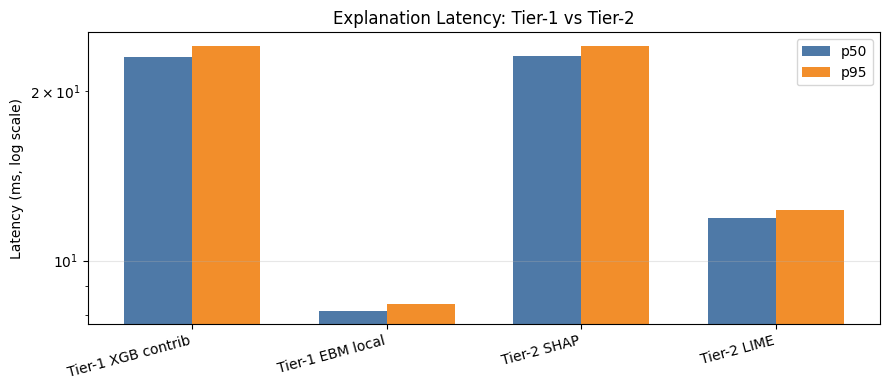

In [72]:

# ─── D1b: Latency bar-chart ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(latency_df))
w = 0.35
bars_p50 = ax.bar(x - w/2, latency_df["p50_ms"], w, label="p50", color="#4E79A7")
bars_p95 = ax.bar(x + w/2, latency_df["p95_ms"], w, label="p95", color="#F28E2B")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(latency_df["method"], rotation=15, ha="right")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Explanation Latency: Tier-1 vs Tier-2")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=150)
plt.show()


### Stability — Top-k Jaccard for LIME (must) [KEEP]

In [73]:

# ─── LIME stability — Jaccard similarity across n repeated runs ──────────
STABILITY_N_RUNS = 10    # re-explain same instance with different seeds
STABILITY_K      = 5     # top-k features to compare

# Pick 20 instances to test stability (mix of malicious + benign)
stab_rows = (
    pd.concat([
        X_test_rt[y_test == 1].head(10),
        X_test_rt[y_test == 0].head(10),
    ])
    .sample(frac=1, random_state=0)  # shuffle
)

def _topk_set(x_row, fn, k):
    contribs = fn(x_row)
    top_idx  = np.argsort(np.abs(contribs))[::-1][:k]
    return frozenset(x_row.index[top_idx])

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 1.0

stability_records = []

for idx, x_row in stab_rows.iterrows():
    # LIME — stochastic
    first_set = _topk_set(x_row, lime_contrib_fn, STABILITY_K)
    sims = []
    for run in range(1, STABILITY_N_RUNS):
        run_set = _topk_set(x_row, lime_contrib_fn, STABILITY_K)
        sims.append(jaccard(first_set, run_set))
    stability_records.append({
        "instance_id": idx,
        "method":      "LIME",
        "mean_jaccard": round(np.mean(sims), 4),
        "std_jaccard":  round(np.std(sims),  4),
        "min_jaccard":  round(np.min(sims),  4),
    })

    # XGB contrib — deterministic (should always be 1.0)
    xgb_set = _topk_set(x_row, xgb_contrib_fn, STABILITY_K)
    xgb_set2 = _topk_set(x_row, xgb_contrib_fn, STABILITY_K)
    stability_records.append({
        "instance_id": idx,
        "method":      "XGB_contrib",
        "mean_jaccard": jaccard(xgb_set, xgb_set2),
        "std_jaccard":  0.0,
        "min_jaccard":  jaccard(xgb_set, xgb_set2),
    })

stability_df = pd.DataFrame(stability_records)
summary = stability_df.groupby("method")[["mean_jaccard","std_jaccard","min_jaccard"]].mean()
print("Top-k stability (Jaccard similarity, higher = more stable):")
print(summary.round(4))
stability_df.to_csv("stability_results.csv", index=False)


Top-k stability (Jaccard similarity, higher = more stable):
             mean_jaccard  std_jaccard  min_jaccard
method                                             
LIME               0.8987       0.1373       0.6548
XGB_contrib        1.0000       0.0000       1.0000


### Faithfulness - Confident-drop under top-k feature removal

In [74]:

# ─── Faithfulness proxy ───────────────────────────────────────────────────
# For each explained instance:
#   delta_topk   = baseline_proba - proba_after_replacing_top_k_with_median
#   delta_random = baseline_proba - proba_after_replacing_random_k_with_median
# A faithful explainer should produce delta_topk >> delta_random.

FAITH_N = 300
FAITH_K = 5     # features to ablate

faith_idx  = X_test_rt.sample(n=FAITH_N, random_state=7).index
X_faith    = X_test_rt.loc[faith_idx]
train_median = X_train_rt.median()   # baseline fill value

def _ablate(x_row, feat_names, fill_vals):
    x_mod = x_row.copy()
    for f in feat_names:
        x_mod[f] = fill_vals[f]
    return x_mod

rng = np.random.default_rng(42)

faith_records = []
for idx, x_row in X_faith.iterrows():
    baseline_proba = float(xgb_rt.predict_proba(x_row.values.reshape(1,-1))[0, 1])

    # top-k by XGB contributions
    contribs   = xgb_contrib_fn(x_row)
    top_k_feat = list(x_row.index[np.argsort(np.abs(contribs))[::-1][:FAITH_K]])
    rand_k_feat = list(rng.choice(x_row.index, size=FAITH_K, replace=False))

    x_topk = _ablate(x_row, top_k_feat, train_median)
    x_rand = _ablate(x_row, rand_k_feat, train_median)

    proba_topk = float(xgb_rt.predict_proba(x_topk.values.reshape(1,-1))[0, 1])
    proba_rand = float(xgb_rt.predict_proba(x_rand.values.reshape(1,-1))[0, 1])

    faith_records.append({
        "instance_id":   idx,
        "baseline_proba": round(baseline_proba, 4),
        "delta_topk":    round(baseline_proba - proba_topk, 4),
        "delta_random":  round(baseline_proba - proba_rand, 4),
    })


In [75]:
faith_df = pd.DataFrame(faith_records)
print("Faithfulness proxy (mean confidence drop after k-feature removal):")
print(f"  mean Δ_topk  : {faith_df['delta_topk'].mean():.4f} ± {faith_df['delta_topk'].std():.4f}")
print(f"  mean Δ_random: {faith_df['delta_random'].mean():.4f} ± {faith_df['delta_random'].std():.4f}")

# t-test: is Δ_topk significantly greater?
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(faith_df['delta_topk'], faith_df['delta_random'], alternative='greater')
print(f"  Paired t-test (Δ_topk > Δ_random): t={t_stat:.3f}, p={p_val:.4f}")
faith_df.to_csv("faithfulness_results.csv", index=False)

Faithfulness proxy (mean confidence drop after k-feature removal):
  mean Δ_topk  : 0.0146 ± 0.4295
  mean Δ_random: -0.0103 ± 0.1042
  Paired t-test (Δ_topk > Δ_random): t=1.067, p=0.1435


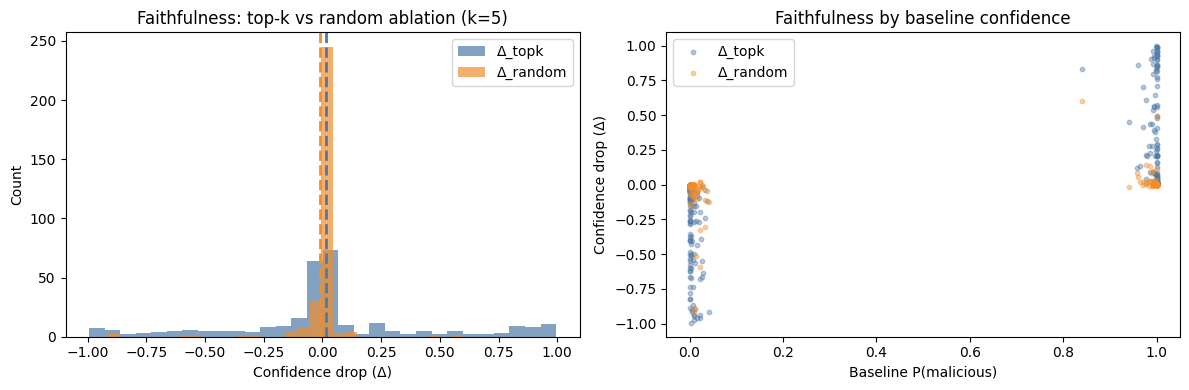

In [76]:

# ─── Faithfulness visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(faith_df['delta_topk'],  bins=30, alpha=0.7, label='Δ_topk',   color="#4E79A7")
axes[0].hist(faith_df['delta_random'],bins=30, alpha=0.7, label='Δ_random', color="#F28E2B")
axes[0].axvline(faith_df['delta_topk'].mean(),  color="#4E79A7", linestyle='--', lw=2)
axes[0].axvline(faith_df['delta_random'].mean(),color="#F28E2B", linestyle='--', lw=2)
axes[0].set_xlabel("Confidence drop (Δ)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Faithfulness: top-k vs random ablation (k={FAITH_K})")
axes[0].legend()

axes[1].scatter(faith_df['baseline_proba'], faith_df['delta_topk'],
                alpha=0.4, s=10, label='Δ_topk', color="#4E79A7")
axes[1].scatter(faith_df['baseline_proba'], faith_df['delta_random'],
                alpha=0.4, s=10, label='Δ_random', color="#F28E2B")
axes[1].set_xlabel("Baseline P(malicious)")
axes[1].set_ylabel("Confidence drop (Δ)")
axes[1].set_title("Faithfulness by baseline confidence")
axes[1].legend()

plt.tight_layout()
plt.savefig("faithfulness_comparison.png", dpi=150)
plt.show()


---
## SHAP Mini-Validation Study
### ANOVA feature set — define FEATURES_ANOVA_K [KEEP]

In [77]:
!pip install statsmodels

In [78]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests


anova_results = []

# Ensure labels are aligned
y_train_series = pd.Series(y_train, index=X_train_rt.index)


for feature in X_train_rt.columns:
    class_0 = X_train_rt.loc[y_train_series == 0, feature]
    class_1 = X_train_rt.loc[y_train_series == 1, feature]

    # Guard against constant features
    if class_0.nunique() <= 1 and class_1.nunique() <= 1:
        continue

    f_stat, p_value = f_oneway(class_0, class_1)

    anova_results.append({
        "feature": feature,
        "f_statistic": f_stat,
        "p_value": p_value
    })

anova_df = pd.DataFrame(anova_results)

# -----------------------------
# Multiple testing correction
# Benjamini–Hochberg (FDR)
# -----------------------------
reject, pvals_corrected, _, _ = multipletests(
    anova_df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

anova_df["p_value_adj"] = pvals_corrected
anova_df["significant"] = reject

# -----------------------------
# Sort by discriminative power
# -----------------------------
anova_df = anova_df.sort_values(
    by=["significant", "f_statistic"],
    ascending=[False, False]
).reset_index(drop=True)

# -----------------------------
# Summary
# -----------------------------
print(f"Total features tested: {len(anova_df)}")
print(f"Statistically significant features (FDR < 0.05): {anova_df['significant'].sum()}")

anova_df.head(10)


Total features tested: 55
Statistically significant features (FDR < 0.05): 54


,feature,f_statistic,p_value,p_value_adj,significant
0,std_Length_of_TCP_packet_header,63096.505205,0.0,0.0,True
1,max_Length_of_TCP_payload,30372.314774,0.0,0.0,True
2,std_Length_of_TCP_payload,30333.445360,0.0,0.0,True
3,max_Length_of_TCP_segment(packet),30327.578567,0.0,0.0,True
4,max_Length_of_IP_packets,30327.578567,0.0,0.0,True
5,std_Length_of_IP_packets,30307.001138,0.0,0.0,True
6,std_Length_of_TCP_segment(packet),30307.001138,0.0,0.0,True
7,Payload_ratio,21113.877502,0.0,0.0,True
8,mean_Interval_of_arrival_time_of_backward_traffic,20623.528813,0.0,0.0,True
9,std_Interval_of_arrival_time_of_backward_traffic,18372.460944,0.0,0.0,True


In [79]:

# ─── ANOVA top-k on training data ────────────────────────────────────────
# anova_df was already computed earlier. Here we just freeze the top-k list.
anova_sorted = anova_df.sort_values("f_statistic", ascending=False)
FEATURES_ANOVA_K = anova_sorted["feature"].head(ANOVA_K).tolist()
# Keep only features that exist in best_features to ensure comparability
FEATURES_ANOVA_K = [f for f in FEATURES_ANOVA_K if f in X_train_rt.columns]
print(f"FEATURES_ANOVA_K ({len(FEATURES_ANOVA_K)}):", FEATURES_ANOVA_K)


FEATURES_ANOVA_K (20): ['std_Length_of_TCP_packet_header', 'max_Length_of_TCP_payload', 'std_Length_of_TCP_payload', 'max_Length_of_TCP_segment(packet)', 'max_Length_of_IP_packets', 'std_Length_of_IP_packets', 'std_Length_of_TCP_segment(packet)', 'Payload_ratio', 'mean_Interval_of_arrival_time_of_backward_traffic', 'std_Interval_of_arrival_time_of_backward_traffic', 'max_TCP_windows_size_value', 'std_Time_difference_between_packets_per_session', 'median_TCP_windows_size_value', 'max_Interval_of_arrival_time_of_backward_traffic', 'std_Interval_of_arrival_time_of_forward_traffic', 'mean_Time_difference_between_packets_per_session', 'mean_Interval_of_arrival_time_of_forward_traffic', 'mean_TCP_windows_size_value', 'max_Time_difference_between_packets_per_session', 'max_Interval_of_arrival_time_of_forward_traffic']


### SHAP global ranking + ANOVA overlap

In [80]:

# ─── E1b: SHAP global summary on 2 000 test samples ──────────────────────────
SHAP_SAMPLE_N = 2000

X_shap_sample = X_test_rt.sample(n=SHAP_SAMPLE_N, random_state=42)
shap_vals_2k  = shap_explainer_xgb.shap_values(X_shap_sample)  # (n, n_feats)
if isinstance(shap_vals_2k, list):
    shap_vals_2k = shap_vals_2k[1]

mean_abs_shap = pd.Series(
    np.abs(shap_vals_2k).mean(axis=0),
    index=X_shap_sample.columns
).sort_values(ascending=False)

FEATURES_SHAP_K = mean_abs_shap.head(SHAP_K).index.tolist()

# ── Overlap ANOVA vs SHAP ──────────────────────────────────────────────────
overlap_anova_shap = set(FEATURES_ANOVA_K) & set(FEATURES_SHAP_K)
print(f"SHAP top-{SHAP_K}:  {FEATURES_SHAP_K}")
print(f"ANOVA top-{ANOVA_K}: {FEATURES_ANOVA_K}")
print(f"Overlap (ANOVA ∩ SHAP): {len(overlap_anova_shap)}/{min(ANOVA_K,SHAP_K)} features")
print(sorted(overlap_anova_shap))


SHAP top-20:  ['std_time_to_live', 'std_Interval_of_arrival_time_of_backward_traffic', 'The_times_of_change_of_payload_per_session', 'mean_TCP_windows_size_value', 'max_Interval_of_arrival_time_of_backward_traffic', 'max_Length_of_IP_packets', 'std_Length_of_IP_packets', 'median_Time_difference_between_packets_per_session', 'max_Time_difference_between_packets_per_session', 'min_time_to_live', 'mean_Interval_of_arrival_time_of_forward_traffic', 'std_TCP_windows_size_value', 'median_Interval_of_arrival_time_of_backward_traffic', 'median_TCP_windows_size_value', 'std_Length_of_TCP_packet_header', 'Length_of_TCP_payload', 'median_Interval_of_arrival_time_of_forward_traffic', 'mean_Interval_of_arrival_time_of_backward_traffic', 'mean_Length_of_TCP_packet_header', 'The_times_of_change_of_TCP_windows_length']
ANOVA top-20: ['std_Length_of_TCP_packet_header', 'max_Length_of_TCP_payload', 'std_Length_of_TCP_payload', 'max_Length_of_TCP_segment(packet)', 'max_Length_of_IP_packets', 'std_Length_

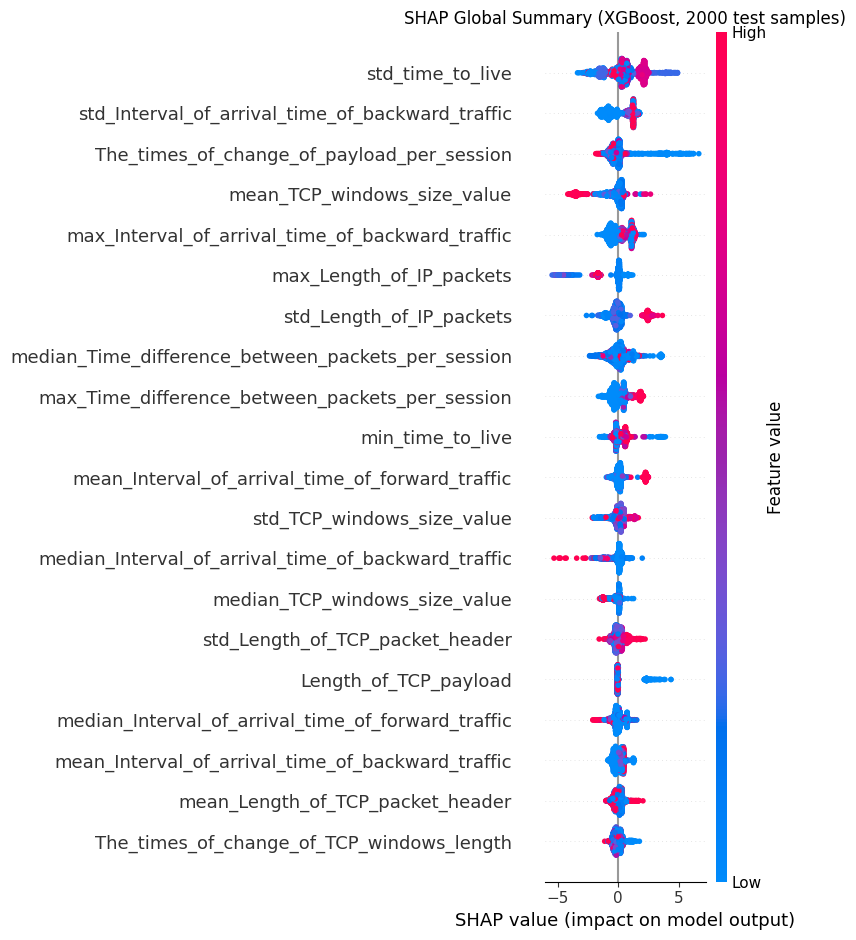

In [81]:

# ─── SHAP global summary plot ───────────────────────────────────────────
import shap
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_2k, X_shap_sample, show=False, max_display=20)
plt.title("SHAP Global Summary (XGBoost, 2000 test samples)")
plt.tight_layout()
plt.savefig("shap_global_summary.png", dpi=150, bbox_inches="tight")
plt.show()


### Local overlap: Tier-1 top-5 vs SHAP top-5 on flagged flows

In [82]:

# ─── Local overlap — Tier-1 vs SHAP on 20 malicious-predicted flows ──────
OVERLAP_N = 20
OVERLAP_K = 5

flagged_mask = xgb_rt.predict(X_test_rt) == 1
X_flagged    = X_test_rt[flagged_mask].head(OVERLAP_N)

overlap_records = []
for idx, x_row in X_flagged.iterrows():
    xgb_top  = set(x_row.index[np.argsort(np.abs(xgb_contrib_fn(x_row)))[::-1][:OVERLAP_K]])
    shap_top = set(x_row.index[np.argsort(np.abs(shap_contrib_fn(x_row)))[::-1][:OVERLAP_K]])

    overlap  = xgb_top & shap_top
    overlap_records.append({
        "instance_id":         idx,
        "overlap_count":       len(overlap),
        "xgb_top5":            ",".join(xgb_top),
        "shap_top5":           ",".join(shap_top),
        "common_features":     ",".join(sorted(overlap)),
    })

overlap_df = pd.DataFrame(overlap_records)
print(f"Mean Tier-1 (XGB) vs SHAP top-{OVERLAP_K} overlap:")
print(f"  {overlap_df['overlap_count'].mean():.2f} / {OVERLAP_K} features agree on average")
print(overlap_df[["overlap_count","common_features"]].to_string(index=False))
overlap_df.to_csv("local_overlap_results.csv", index=False)


Mean Tier-1 (XGB) vs SHAP top-5 overlap:
  5.00 / 5 features agree on average
 overlap_count                                                                                                                                                                                                          common_features
             5                                   max_Time_difference_between_packets_per_session,mean_time_to_live,median_Interval_of_arrival_time_of_forward_traffic,std_Interval_of_arrival_time_of_backward_traffic,std_time_to_live
             5                                                                                         The_times_of_change_of_payload_per_session,max_Length_of_IP_packets,min_time_to_live,std_TCP_windows_size_value,std_time_to_live
             5                                                   Length_of_TCP_payload,The_times_of_change_of_TCP_windows_length,The_times_of_change_of_payload_per_session,mean_Length_of_TCP_packet_header,std_TCP_windows_size_

### Runtime comparison: Tier-1 vs Tier-2

In [83]:

# ─── Runtime comparison summary table ─────────────────────────────────────
print("=== Explanation Runtime Comparison ===")
runtime_summary = latency_df[["method","p50_ms","p95_ms","throughput_eps"]].copy()
runtime_summary.columns = ["Method","p50 (ms)","p95 (ms)","Throughput (exp/s)"]
print(runtime_summary.to_string(index=False))

# Tier-1 vs Tier-2 speedup
t1_p50 = latency_df.loc[latency_df.method == "Tier-1 XGB contrib", "p50_ms"].values[0]
shap_p50 = latency_df.loc[latency_df.method == "Tier-2 SHAP", "p50_ms"].values[0]
lime_p50 = latency_df.loc[latency_df.method == "Tier-2 LIME", "p50_ms"].values[0]
print(f"\nSpeedup Tier-1 vs SHAP : {shap_p50/t1_p50:.0f}x")
print(f"Speedup Tier-1 vs LIME : {lime_p50/t1_p50:.0f}x")


=== Explanation Runtime Comparison ===
            Method  p50 (ms)  p95 (ms)  Throughput (exp/s)
Tier-1 XGB contrib    22.983    24.057                41.1
  Tier-1 EBM local     8.148     8.370               122.3
       Tier-2 SHAP    23.083    23.980                42.0
       Tier-2 LIME    11.880    12.293                82.4

Speedup Tier-1 vs SHAP : 1x
Speedup Tier-1 vs LIME : 1x


---
## ANOVA Feature Set — Retraining and Comparison

In [84]:

# ─── Train RF+XGB on ANOVA top-k and compare to SHAP top-k ────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Restrict to columns that exist in training data
feat_anova_avail = [f for f in FEATURES_ANOVA_K if f in X_train_rt.columns]
feat_shap_avail  = [f for f in FEATURES_SHAP_K  if f in X_train_rt.columns]
feat_inter_avail = sorted(set(feat_anova_avail) & set(feat_shap_avail))

comparison_rows = []
for feat_label, feats in [
    ("FEATURES_FULL",          FEATURES_FULL),
    (f"FEATURES_ANOVA_{ANOVA_K}", feat_anova_avail),
    (f"FEATURES_SHAP_{SHAP_K}",  feat_shap_avail),
    ("FEATURES_INTERSECTION",  feat_inter_avail),
]:
    if not feats:
        continue
    feats = [f for f in feats if f in X_train_rt.columns]
    _Xtr = X_train_rt[feats]; _Xte = X_test_rt[feats]
    for mname, m in [
        ("RF",     RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)),
        ("XGBoost",XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=9,
                                  n_jobs=-1, random_state=42, eval_metric="logloss")),
    ]:
        m.fit(_Xtr, y_train)
        ev = evaluate_classifier(m, _Xte, y_test, verbose=False)
        comparison_rows.append({
            "feature_set": feat_label,
            "n_features":  len(feats),
            "model":       mname,
            "accuracy":    round(ev["accuracy"], 4),
            "f1":          round(ev["f1"],       4),
            "roc_auc":     round(ev["roc_auc"],  4),
        })

comparison_df = pd.DataFrame(comparison_rows)
print("Feature-set comparison:")
print(comparison_df.to_string(index=False))
comparison_df.to_csv("feature_set_comparison.csv", index=False)


Feature-set comparison:
          feature_set  n_features   model  accuracy     f1  roc_auc
        FEATURES_FULL          65      RF    0.9998 0.9998   1.0000
        FEATURES_FULL          65 XGBoost    0.9997 0.9997   1.0000
    FEATURES_ANOVA_20          20      RF    0.9981 0.9981   1.0000
    FEATURES_ANOVA_20          20 XGBoost    0.9924 0.9922   0.9997
     FEATURES_SHAP_20          20      RF    1.0000 1.0000   1.0000
     FEATURES_SHAP_20          20 XGBoost    0.9990 0.9989   1.0000
FEATURES_INTERSECTION          10      RF    0.9976 0.9975   1.0000
FEATURES_INTERSECTION          10 XGBoost    0.9938 0.9936   0.9998


---
## Summary Dashboard

In [85]:

# ─── G: Consolidated pipeline summary ────────────────────────────────────────
print("=" * 65)
print("  TWO-TIER XAI PIPELINE — RESULTS SUMMARY")
print("=" * 65)

print("\n[1] MODEL PERFORMANCE (best-feature subset)")
print(f"  RF   — acc={evaluate_rf_rt['accuracy']:.4f}, f1={evaluate_rf_rt['f1']:.4f}, auc={evaluate_rf_rt['roc_auc']:.4f}")
print(f"  XGB  — acc={evaluate_xgb_rt['accuracy']:.4f}, f1={evaluate_xgb_rt['f1']:.4f}, auc={evaluate_xgb_rt['roc_auc']:.4f}")
print(f"  EBM  — acc={evaluate_xxgb['accuracy']:.4f}, f1={evaluate_xxgb['f1']:.4f}, auc={evaluate_xxgb['roc_auc']:.4f}")

print("\n[2] LATENCY (p50 / p95 ms)")
for _, row in latency_df.iterrows():
    print(f"  {row['method']:<26} p50={row['p50_ms']:>8.3f}  p95={row['p95_ms']:>8.3f}  ({row['throughput_eps']:.0f} exp/s)")

print("\n[3] STABILITY (mean Jaccard top-k agreement)")
for method, grp in stability_df.groupby("method"):
    print(f"  {method:<18} mean={grp['mean_jaccard'].mean():.4f} ± {grp['std_jaccard'].mean():.4f}")

print("\n[4] FAITHFULNESS (mean confidence drop, XGB contributions)")
print(f"  Δ_topk  : {faith_df['delta_topk'].mean():.4f} ± {faith_df['delta_topk'].std():.4f}")
print(f"  Δ_random: {faith_df['delta_random'].mean():.4f} ± {faith_df['delta_random'].std():.4f}")

print("\n[5] TIER-2 TRIGGER RATE")
print(f"  {flagged_count}/{BATCH_SIZE} = {flagged_count/BATCH_SIZE*100:.1f}% of flows triggered Tier-2")

print("\n[6] SHAP / ANOVA OVERLAP")
print(f"  ANOVA top-{ANOVA_K} ∩ SHAP top-{SHAP_K}: {len(overlap_anova_shap)} features")

print("\n[7] LOCAL XGB vs SHAP OVERLAP (20 flagged instances)")
print(f"  Mean top-5 feature agreement: {overlap_df['overlap_count'].mean():.2f}/5")
print("=" * 65)


  TWO-TIER XAI PIPELINE — RESULTS SUMMARY

[1] MODEL PERFORMANCE (best-feature subset)
  RF   — acc=0.9998, f1=0.9997, auc=1.0000
  XGB  — acc=0.9997, f1=0.9997, auc=1.0000
  EBM  — acc=0.9989, f1=0.9989, auc=0.9998

[2] LATENCY (p50 / p95 ms)
  Tier-1 XGB contrib         p50=  22.983  p95=  24.057  (41 exp/s)
  Tier-1 EBM local           p50=   8.148  p95=   8.370  (122 exp/s)
  Tier-2 SHAP                p50=  23.083  p95=  23.980  (42 exp/s)
  Tier-2 LIME                p50=  11.880  p95=  12.293  (82 exp/s)

[3] STABILITY (mean Jaccard top-k agreement)
  LIME               mean=0.8987 ± 0.1373
  XGB_contrib        mean=1.0000 ± 0.0000

[4] FAITHFULNESS (mean confidence drop, XGB contributions)
  Δ_topk  : 0.0146 ± 0.4295
  Δ_random: -0.0103 ± 0.1042

[5] TIER-2 TRIGGER RATE
  253/500 = 50.6% of flows triggered Tier-2

[6] SHAP / ANOVA OVERLAP
  ANOVA top-20 ∩ SHAP top-20: 10 features

[7] LOCAL XGB vs SHAP OVERLAP (20 flagged instances)
  Mean top-5 feature agreement: 5.00/5


## Model Testing using Best Features on Aggregated Dataset

In [86]:
rf_best = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf_best.fit(X_train[best_features], y_train)
evaluate_rf_best = evaluate_classifier(rf_best, X_test[best_features], y_test)

Accuracy: 0.999939
F1:       0.999937
ROC-AUC:  0.9999999827474553

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33715
           1       1.00      1.00      1.00     31805

    accuracy                           1.00     65520
   macro avg       1.00      1.00      1.00     65520
weighted avg       1.00      1.00      1.00     65520

Confusion matrix:
 [[33711     4]
 [    0 31805]]


In [87]:
aggregated_data = "./agg-data/dataset.csv"
agg_df_raw = pd.read_csv(aggregated_data, header=None, low_memory=False)

In [88]:
aggregated_data_1 = "./agg-data/dataset1.csv"

agg_df_raw = pd.read_csv(aggregated_data_1, header=None, low_memory=False)

In [89]:
agg_df_raw.sample(n=10)


,0,1,2,3,4,5,6,7,8,9,10
4738,CQH6WU3XF0h8fYj8D6,0.0,2340.4419999997117,1476.5343333333476,3443.2102999999643,252.26666666666668,822.2654999999577,787.7583148377423,22.88688541085317,0.0,1
6757,CPFWZN3m9XNYWioEgd,6.0,1100.3849999979138,226.26583333233916,159.21422222163528,7943.294117647059,7.406500000797678,436.2127347874124,292.4003978230174,0.0,1
6962,C7r0Gf2ugk1LaRb0k2,6.0,9121.84900000284,1556.2911666662937,1178.8642499996058,8440.125,22.95800000138115,3706.466290869466,220.2698345212072,0.0,1
8704,CRMFTS24fe3uzCDHg3,6.0,9373.877999998513,1621.7123333335621,1397.9785714286013,9002.4,15.59350000025006,3799.0326035505154,267.70555964840673,0.0,1
11492,CzziMv2Slp0fYt5pOb,0.0,0.9491443634033203,0.17801920572916666,1.1889934539794922,15550.4,0.9145736694335938,0.37798718414044513,0.0,0.0,1
5099,CKun6eYgw8Vo4HD3i,4.0,9634.40399999672,4965.448499999184,765.7682307695862,8035.470588235294,142.60250000370434,6602.900190212972,205.1115908618583,0.0,1
4474,C6VTab1QSzFEtZyOZ9,0.0,15848.878999997396,1986.5006250001898,7.0595714288564135,8034.705882352941,2.852999998140149,5601.250434421911,7.482332130936655,0.0,1
10165,CixKnS3ZFsYoHeIU8i,4.0,3960.726022720337,1226.0710000991821,586.0125488705105,13077.6,2.230525016784668,1875.8013472969392,474.46089707914064,0.0,1
9370,Cc4GpH2apEZQQMO7va,6.0,9490.422999995644,1659.13866666718,1251.9096249998256,8439.75,45.82299999310635,3836.882249408032,276.9466555132956,0.0,1
3711,C1ACdZ2EbQWKHQ8ifa,0.0,16113.394999993034,2018.4831250007846,5.638857141353323,8034.705882352941,2.7130000016768463,5695.206171784116,7.482332130936655,0.0,1


## Explainable AI (XAI): SHAP and LIME

### LIME: Local Interpretable Model-agnostic Explanations

In [90]:
!pip install lime

In [91]:
from interpret.blackbox import LimeTabular
from lime.lime_tabular import LimeTabularExplainer

In [92]:
explainer = LimeTabularExplainer(training_data=X_train.to_numpy(),
                                 feature_names=X_train.columns.tolist(),
                                 class_names=[str(c) for c in rf.classes_],
                                 mode="classification",
                                 discretize_continuous=False,
                                 feature_selection="highest_weights"
                                )

exp = explainer.explain_instance(data_row=X_test.to_numpy()[0],
                                 num_features=10,
                                 predict_fn=rf.predict_proba,
                                 num_samples=5000, 
                                 top_labels=1 
                                )

Row index: 0
Predicted class: 0 (class name: 0)
Predicted probabilities: {'0': np.float64(1.0), '1': np.float64(0.0)}
True class: 0

Explanation (top features):
('std_Change_values_of_TCP_windows_length_per_session', -0.008245257648586302)
('max_Interval_of_arrival_time_of_backward_traffic', -0.0063423949716656)
('std_TCP_windows_size_value', -0.006295156542324678)
('max_Time_difference_between_packets_per_session', -0.00469405702905721)
('std_forward_pkt_length', 0.00411712839704971)
('max_Length_of_TCP_packet_header', 0.003933347303254358)
('Length_of_TCP_payload', 0.0028086265159734105)
('max_time_to_live', -0.0022878184035231173)
('mean_Length_of_TCP_packet_header', -0.0022710853135589843)
('flow duration', 0.0010287663282287998)


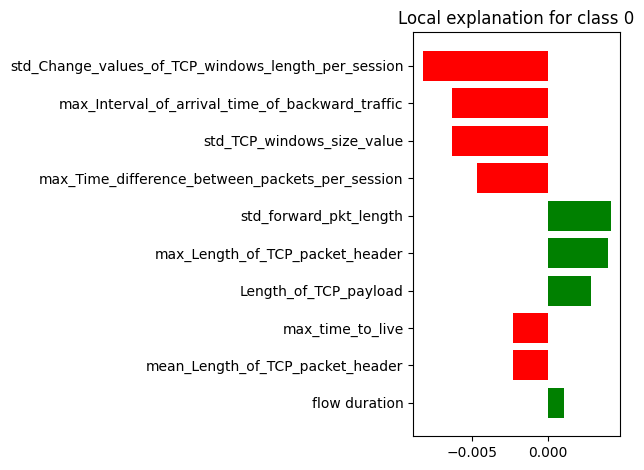

In [93]:
# pick the row you explained (match what you passed to explain_instance)
i = 0

# model predictions
pred_class = rf.predict(X_test)[i]
pred_proba = rf.predict_proba(X_test)[i]

# label names (binary example)
class_names = [str(c) for c in rf.classes_]   # e.g. ['0', '1']

print(f"Row index: {i}")
print(f"Predicted class: {pred_class} (class name: {class_names[list(rf.classes_).index(pred_class)]})")
print(f"Predicted probabilities: {dict(zip(class_names, pred_proba))}")
print(f"True class: {y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]}")

print("\nExplanation (top features):")
label_to_show = exp.top_labels[0]  # or use 1 for the positive class if you want
print("\n".join(map(str, exp.as_list(label=label_to_show))))

# Visualize explanation
fig = exp.as_pyplot_figure(label=label_to_show)
plt.tight_layout()
plt.show()


In [94]:
# Initilize Lime for Tabular data
# lime = LimeTabular(rf, X_train, random_state=1)

# Get local explanations

# lime_local = lime.explain_local(X_test[-20:],
# y_test[-20:],
# name='LIME')

# show(lime_local, 0)

# SAVING MODELS

In [96]:
target_cols = ['label']

In [100]:
scaler_rt, X_rt, y_rt = preprocess(main_df[REALTIME_SAFE_FEATURES])
scaler_best, X_best, y_best = preprocess(main_df[best_features])

In [101]:
import joblib

mapper = {
    'rf_best': rf_best,
    'xgb_rt': xgb_rt,
    'xxgb': xxgb,
    'scaler_rt': scaler_rt,
    'scaler_best': scaler_best,
    'REALTIME_SAFE_FEATURES': REALTIME_SAFE_FEATURES,
    'BEST_FEATURES': best_features, 
    'target_cols' : target_cols,
    }

joblib.dump(mapper, 'mapper')

['mapper']

In [ ]:
!find . -maxdepth 1 -type f -print | zip analysis_archive.zip -@

  adding: mapper

# EXTRA

### SHAP: SHapley Additive exPlanation

In [ ]:
!pip install "numpy<2.4"  # e.g., 2.3.x
!pip install -U numba shap

In [ ]:
import shap

In [ ]:
# shap_explainer = shap.TreeExplainer(rf)

In [ ]:
# Calculate shapley values for test data
# start_index = 5000
# end_index = 5001

X_test_sample = X_test.sample(n=1000, replace=False, random_state=42)

# Create SHAP explainer
explainer = shap.Explainer(rf)
shap_values = explainer.shap_values(X_test_sample)

# shap_values = explainer.shap_values(X_test[start_index: end_index])
# X_test[start_index: end_index]

In [ ]:
# %% Investigating the values (classification problem)
# class 0 = contribution to class 1
# class 1 = contribution to class 2
print(shap_values[0].shape)
shap_values

(89, 2)


array([[[ 2.33496040e-03, -2.33496040e-03],
        [ 1.16828781e-03, -1.16828781e-03],
        [ 1.56076010e-03, -1.56076010e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00],
        [-2.15755257e-04,  2.15755257e-04],
        [ 1.73038800e-03, -1.73038800e-03]],

       [[ 8.07516434e-04, -8.07516434e-04],
        [ 2.72190158e-04, -2.72190158e-04],
        [ 5.79395809e-04, -5.79395809e-04],
        ...,
        [ 0.00000000e+00,  0.00000000e+00],
        [ 4.77650850e-04, -4.77650850e-04],
        [-3.74582707e-03,  3.74582707e-03]],

       [[ 1.00135700e-03, -1.00135700e-03],
        [ 3.13278834e-04, -3.13278834e-04],
        [ 5.73523431e-04, -5.73523431e-04],
        ...,
        [ 0.00000000e+00,  0.00000000e+00],
        [-4.91778360e-03,  4.91778360e-03],
        [-3.88318417e-03,  3.88318417e-03]],

       ...,

       [[ 1.31452843e-03, -1.31452843e-03],
        [ 6.08679563e-05, -6.08679563e-05],
        [ 7.71258984e-04, -7.71258984e-04],
        ...,
     

In [ ]:
shap.initjs()

class_idx = 0  # explain class 1
row_idx = 13    

# X_slice = X_test.iloc[start_index:end_index]  # DataFrame slice

prediction = rf.predict(X_test_sample)
print (f"The RF predicted: {prediction[row_idx]}")

# shap_values is (n_samples, n_features, n_classes)
sv = shap_values[:, :, class_idx]            # -> (n_samples, n_features)

# single-row force plot needs 1D shap values and 1 row of X
shap.force_plot(
    explainer.expected_value[class_idx],
    sv[row_idx, :],
    X_test_sample.iloc[row_idx, :]
)


The RF predicted: 1


In [ ]:
prediction[3]

np.int64(0)

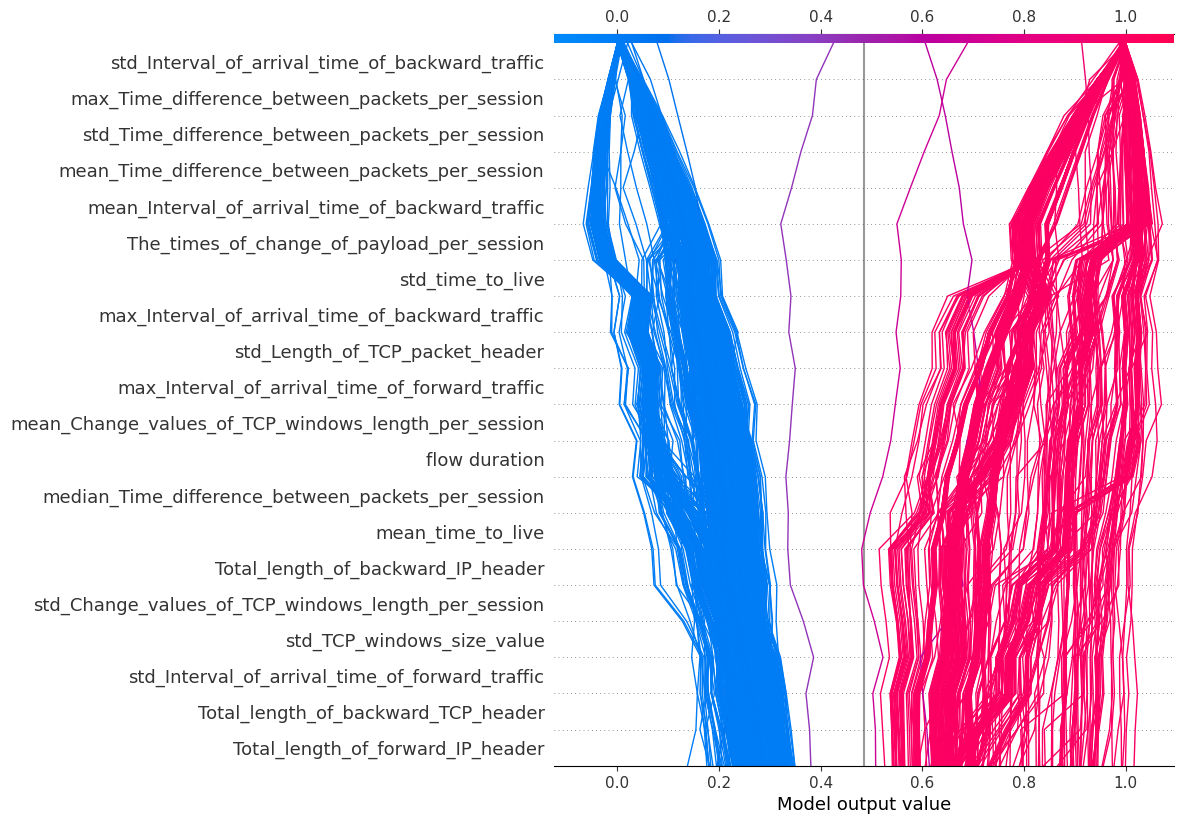

In [ ]:
## Display the decision plot for the target label “1”
# shap.decision_plot(explainer.expected_value[1], shap_values[1], X_test_sample.columns.tolist())


sv1 = shap_values[:, :, 1]  # take class 1 channel

shap.decision_plot(
    explainer.expected_value[1],
    sv1,
    X_test_sample,
    feature_names=X_test_sample.columns.tolist()
)



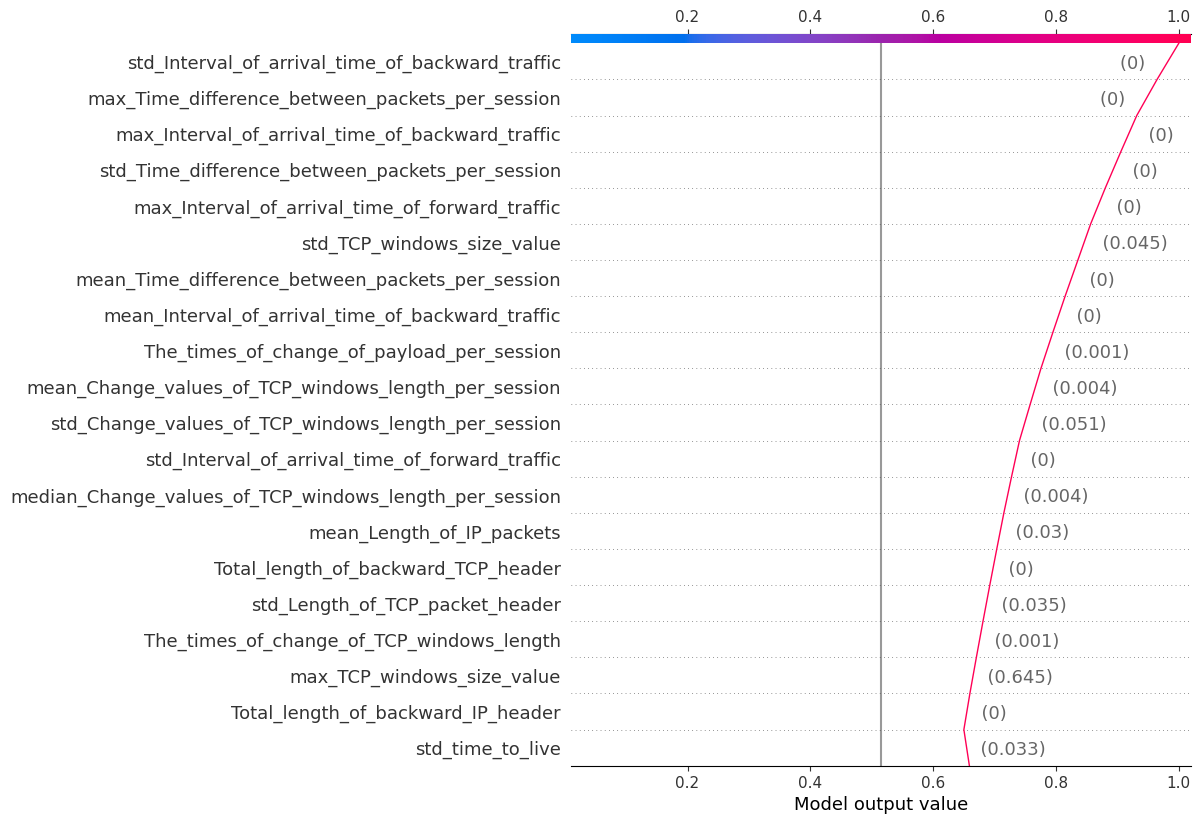

In [ ]:
## Display the decision plot for the target label “0”
# shap.decision_plot(explainer.expected_value[0], shap_values[0], X_test_sample.columns)


i = 0

# 3D case:
sv_row0 = shap_values[i, :, 0]


shap.decision_plot(
    explainer.expected_value[0],
    sv_row0,
    X_test_sample.iloc[i],
    feature_names=X_test_sample.columns.tolist()
)

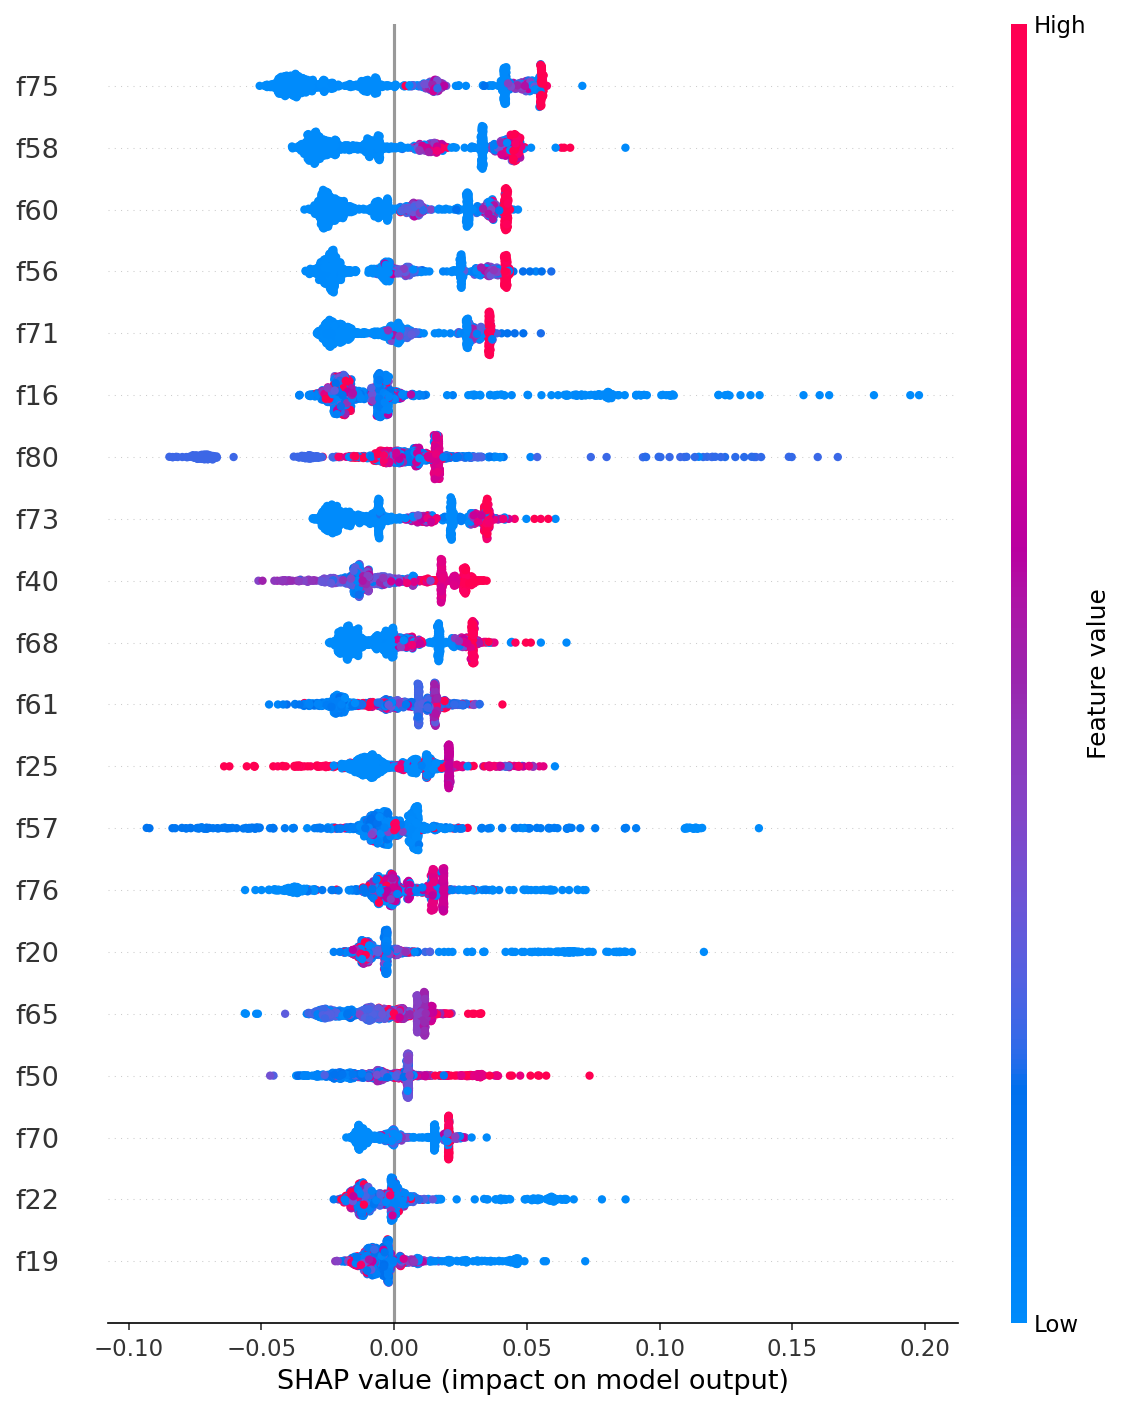

encoded                                       original_feature
     f0                                          Payload_ratio
     f1                                   Length_of_IP_packets
     f2                                  Length_of_TCP_payload
     f3                            Length_of_TCP_packet_header
     f4                             Length_of_IP_packet_header
     f5                                 TCP_windows_size_value
     f6                          Length_of_TCP_segment(packet)
     f7            Time_difference_between_packets_per_session
     f8        Change_values_of_TCP_windows_length_per_session
     f9            Interval_of_arrival_time_of_forward_traffic
    f10           Interval_of_arrival_time_of_backward_traffic
    f11                                           Time_to_live
    f12              Ratio_to_previous_packets_in_each_session
    f13                  Total_length_of_IP_packet_per_session
    f14                         Total_Time_to_live_per_

In [ ]:
# Visualize Global features
# Feature summary

# shap.summary_plot(shap_values, X_test_sample)

# --- 1) Build a temporary encoded-name copy ---
X_plot = X_test_sample.copy()

encoded_names = [f"f{i}" for i in range(X_plot.shape[1])]
name_map = dict(zip(encoded_names, X_plot.columns))          # encoded -> original
inv_map  = dict(zip(X_plot.columns, encoded_names))          # original -> encoded
X_plot.columns = encoded_names

# --- 2) Select SHAP matrix for class 1 correctly ---
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# --- 3) Plot wider ---
plt.figure(figsize=(22, 10), dpi=150)
shap.summary_plot(sv, X_plot, show=False, max_display=20)
plt.tight_layout()
plt.show()

# --- 4) Print the legend mapping (so you can interpret the plot) ---
mapping_df = pd.DataFrame({
    "encoded": encoded_names,
    "original_feature": list(name_map.values())
})
print(mapping_df.to_string(index=False))

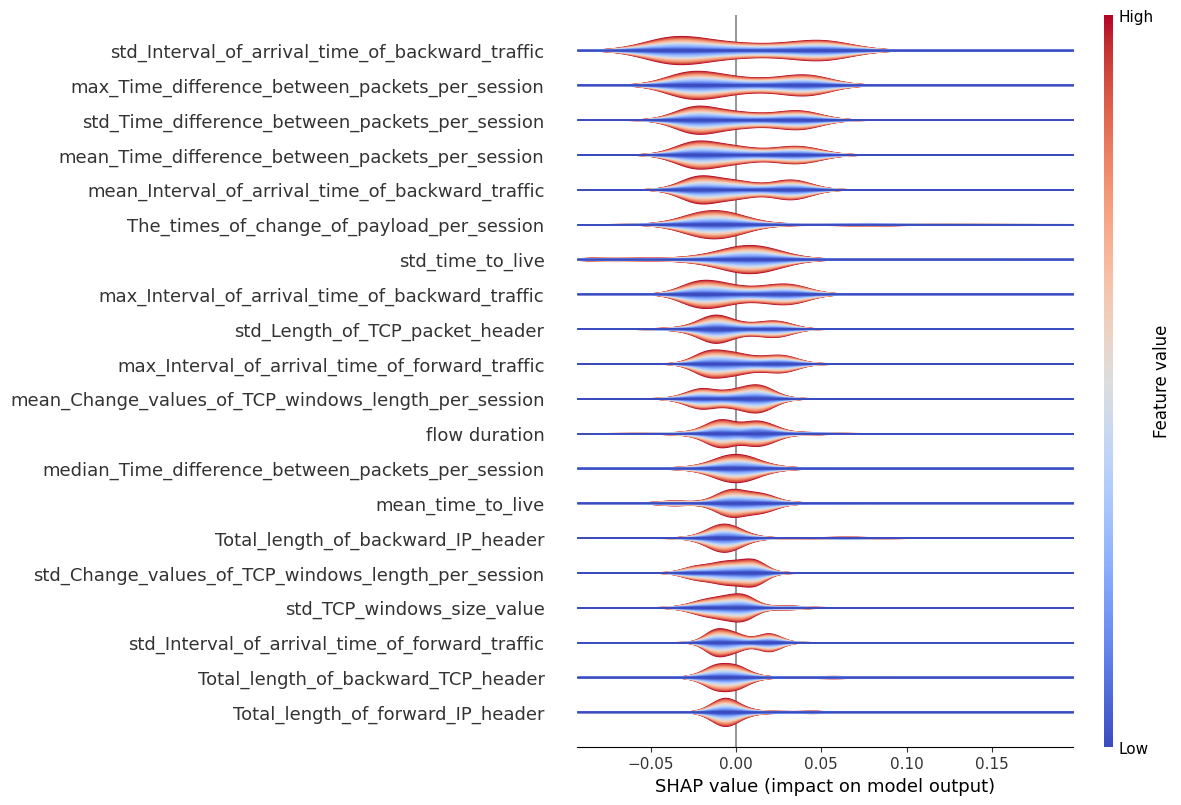

In [ ]:
# shap.plots.violin(shap_values[0], features=X_train, feature_names=X_train.columns.tolist(), plot_type="layered_violin")

# pick the positive class shap values -> shape (n_samples, n_features)
sv_pos = shap_values[:, :, 1]

# Make sure features has the same rows as sv_pos (your sv_pos is for 1000 samples)
X_feat = X_train.iloc[:sv_pos.shape[0], :]

shap.plots.violin(
    sv_pos,
    features=X_feat,
    feature_names=X_feat.columns.tolist(),
    plot_type="layered_violin"
)

In [ ]:
# shap.plots.waterfall(shap_values[0])

In [ ]:
# shap.plots.beeswarm(shap_values)

In [ ]:
# shap.plots.force(shap_values[:500])

## PDP: Partial Dependence Plots

In [ ]:
!pip install pdpbox
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 828.5 kB/s eta 0:00:000:00:01


In [ ]:
from pdpbox import pdp
# get_dataset, info_plots

feature_names=X_train.columns.tolist()

In [ ]:
# from sklearn import tree
# import graphviz

# rf_graph = tree.export_graphviz(rf, out_file=None, feature_names=feature_names,filled = True)
# graphviz.Source(rf_graph)

In [ ]:
# Create the data that we will plot
pdp_goals = pdp.pdp_isolate(model=rf, dataset=X_test, model_features=feature_names, feature='max_Length_of_TCP_segment(packet)')

# plot it
pdp.pdp_plot(pdp_goals, 'max_Length_of_TCP_segment(packet)')
plt.show()

In [ ]:
features_to_plot = ['max_Length_of_TCP_segment(packet)','std_TCP_windows_size_value']
inter1  =  pdp.pdp_interact(model=rf, dataset=X_test, model_features=feature_names, features=features_to_plot)

pdp.pdp_interact_plot(pdp_interact_out=inter1, feature_names=features_to_plot, plot_type='contour', plot_pdp=True)
plt.show()

## Anomaly Detection (Isolation Forest)

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
# train ONLY on normal
X_train_normal = X_train[y_train == 0]

iso = IsolationForest(
    n_estimators=600,
    contamination=0.1,  # thresholding comes later
    max_samples=250000,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_normal)

test_score = -iso.score_samples(X_test)     # higher = more anomalous
df_test = df.loc[X_test.index].copy()
df_test["anomaly_score"] = test_score

In [ ]:
# Example: allow 1% false positives on NORMALS in the test set
normal_scores = df_test.loc[y_test == 0, "anomaly_score"]

threshold = normal_scores.quantile(0.99)   # top 1% most suspicious normals

df_test["is_anomaly"] = (df_test["anomaly_score"] >= threshold).astype(int)


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

y_true = y_test.values
y_pred = df_test["is_anomaly"].values
scores = df_test["anomaly_score"].values

print(classification_report(y_true, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_true, scores))
print("PR-AUC:", average_precision_score(y_true, scores))


              precision    recall  f1-score   support

           0     0.6591    0.9900    0.7914    134688
           1     0.9774    0.4578    0.6236    127197

    accuracy                         0.7315    261885
   macro avg     0.8183    0.7239    0.7075    261885
weighted avg     0.8137    0.7315    0.7099    261885

ROC-AUC: 0.8131840841048906
PR-AUC: 0.8337315325329921


In [ ]:
from sklearn.metrics import precision_recall_curve


scores = -iso.score_samples(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, scores)

# compute F1 for each threshold (thresholds is length-1 vs precision/recall)
f1s = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = np.argmax(f1s)
best_thr = thresholds[best_idx]

y_pred = (scores >= best_thr).astype(int)

print("Best threshold:", best_thr)
print("Best F1:", f1s[best_idx])

Best threshold: 0.3596817942583211
Best F1: 0.7323980016365096


## ANOVA

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests


anova_results = []

# Ensure labels are aligned
y_train_series = pd.Series(y_train, index=X_train.index)


for feature in X_train.columns:
    class_0 = X_train.loc[y_train_series == 0, feature]
    class_1 = X_train.loc[y_train_series == 1, feature]

    # Guard against constant features
    if class_0.nunique() <= 1 and class_1.nunique() <= 1:
        continue

    f_stat, p_value = f_oneway(class_0, class_1)

    anova_results.append({
        "feature": feature,
        "f_statistic": f_stat,
        "p_value": p_value
    })

anova_df = pd.DataFrame(anova_results)

# -----------------------------
# Multiple testing correction
# Benjamini–Hochberg (FDR)
# -----------------------------
reject, pvals_corrected, _, _ = multipletests(
    anova_df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

anova_df["p_value_adj"] = pvals_corrected
anova_df["significant"] = reject

# -----------------------------
# Sort by discriminative power
# -----------------------------
anova_df = anova_df.sort_values(
    by=["significant", "f_statistic"],
    ascending=[False, False]
).reset_index(drop=True)

# -----------------------------
# Summary
# -----------------------------
print(f"Total features tested: {len(anova_df)}")
print(f"Statistically significant features (FDR < 0.05): {anova_df['significant'].sum()}")

anova_df.head(10)


## FEATURE SELECTION FOR OPTIMAL RETRAINING

In [ ]:
# !pip install skfeature-chappers

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from skfeature.function.similarity_based import fisher_score

In [ ]:
### Information Gain

importances = mutual_info_classif(X_train, y_train)
feat_importances = pd.Series(importances, index=X_train.columns).sort_values()
plt.figure(figsize=(18, 12), dpi=150)
feat_importances.plot(kind="barh")
plt.tight_layout()
plt.show()

### Chi-square Test

In [ ]:
# Convert to categorical data by converting data to integers
X_cat = X_train.astype(int)

# Three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k=7)
X_kbest_features = chi2_features.fit_transform(X_cat, y_train)

# Reduced features
print('Original feature number:', X_cat.shape[1])
print('Reduced feature number:', X_kbest_features.shape[1])

Original feature number: 89
Reduced feature number: 7


In [ ]:
X_kbest_features

### Fisher Score

In [ ]:
# Calculating scores
ranks = fisher_score.fisher_score(X_train.to_numpy(), y_train.to_numpy())

# Plotting the ranks
feat_importances = pd.Series(ranks, index=X_train.columns).sort_values()
feat_importances.plot(kind='barh', color='teal')
plt.show()

## TRAINING - CONVENTIONAL FEATURE SET

### FOS: Further Optimized Statistical Feature Set

In [ ]:
feature_dfs[1]

,57,101,83,89,28,20,71,102,41,93,97,104,99
0,mean_TCP_windows_size_value,Source_port,max_Interval_of_arrival_time_of_forward_traffic,max_Interval_of_arrival_time_of_backward_traffic,flow duration,Total_length_of_forward_payload,max_Time_difference_between_packets_per_session,std_forward_pkt_length,max_Length_of_TCP_payload,mean_time_to_live,std_time_to_live,duration_forward,label
1,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
2,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
3,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
4,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637013,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637014,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637015,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637016,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0


In [ ]:
FOS = feature_dfs[1].copy(deep=True)

In [ ]:
FOS.columns = FOS.iloc[0] 
FOS = FOS.iloc[1:].reset_index(drop=True) 

In [ ]:
FOS

,mean_TCP_windows_size_value,Source_port,max_Interval_of_arrival_time_of_forward_traffic,max_Interval_of_arrival_time_of_backward_traffic,flow duration,Total_length_of_forward_payload,max_Time_difference_between_packets_per_session,std_forward_pkt_length,max_Length_of_TCP_payload,mean_time_to_live,std_time_to_live,duration_forward,label
0,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
1,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
2,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
3,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
4,4818.074074074074,60140,550.0911560058594,550.0521478652954,1028.9012088775637,1013.0,550.002965927124,185.67841075963088,517.0,53.888888888888886,10.492795882513809,1028.790806055069,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637012,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637013,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637014,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0
1637015,3228.030150753769,3223,40173.65947699547,40173.87525701523,76239.4197769165,48909.0,40173.65947699547,582.1635906521394,1448.0,51.58793969849246,12.986698075759543,1.6097080707550049,0


In [ ]:
# import joblib

# # Load the data from a joblib file
# data = joblib.load('CSN_map')

# # Now you can use the loaded data
# print(data)